# Somatic Mutation Accumulation Around TSSs
## Using SomaMutDB Data × FANTOM5/GENCODE TSS Annotations

Pipeline:
1. Download & compile somatic mutations from SomaMutDB
2. Reformat to `chr  pos  ref>alt`
3. Map mutations to ±1kb TSS windows
4. Reverse complement for − strand
5. Count mutations by position × type (12 mutation types)
6. Get nucleotide content per position (bedtools getfasta)
7. Parse CpG vs non-CpG mutations
8. Count non-CpG mutations separately
9. Nucleotide content with CpG context

---
# 1. Configuration

In [2]:
import os
import csv
import gzip
import glob
import tarfile
import subprocess
import logging
import concurrent.futures
from collections import defaultdict
from urllib.request import urlretrieve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# ============================================================
# EDIT THESE PATHS
# ============================================================

# TSS annotation file (FANTOM5/GENCODE v40, hg38, ±1kb)
TSS_FILE = '/home/alexpalazzo1/Documents/Tina/Rare_SNP/Fantom5_CAGE_hg38_gencode.v40_TSS_1kb_geneID.txt'

# Reference genome FASTA (hg38)
REFERENCE_FASTA = '/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homo_sapiens.GRCh38.dna.toplevel.fa'

# Working directory
WORK_DIR = './somamutdb_data'
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(os.path.join(WORK_DIR, 'output'), exist_ok=True)

# Genome build
GENOME_BUILD = 'hg38'

# Parallel processing
CHUNK_SIZE = 500000

# Datasets to EXCLUDE (DNA repair defects / disease tissue)
EXCLUDE_IDS = {'3', '17', '18', '20', '23', '41', '43', '50', '104'}

print('Configuration loaded.')

Configuration loaded.


---
# 2. Dataset Definitions & Download

## 2.1 Define all SomaMutDB datasets

In [3]:
BASE_URL = 'https://somamutdb.org/static/vcf'

DATASETS = {
    '1':   {'pub': 'Blokzijl_2016_Nature',         'tissue': 'Colon,Liver,SmallIntestine'},
    '2':   {'pub': 'Bae_2018_Science',              'tissue': 'Brain'},
    '3':   {'pub': 'Lodato_2018_Science',           'tissue': 'Brain'},
    '4':   {'pub': 'LeeSix_2018_Nature',            'tissue': 'Blood,BoneMarrow'},
    '6':   {'pub': 'Rouhani_2016_PLoSGenet',        'tissue': 'iPSC'},
    '8':   {'pub': 'Kwon_2017_PNAS',                'tissue': 'iPSC'},
    '9':   {'pub': 'Li_2020_Science',               'tissue': 'Bladder,Ureter'},
    '10':  {'pub': 'Cooper_2015_NatGenet',          'tissue': 'Prostate'},
    '11':  {'pub': 'Milholland_2017_GenomeRes',     'tissue': 'iPSC'},
    '12':  {'pub': 'Franco_2018_NatComm',           'tissue': 'SkeletalMuscle'},
    '16':  {'pub': 'Lawson_2020_Science',           'tissue': 'Bladder'},
    '17':  {'pub': 'Nanki_2020_Nature',             'tissue': 'Colon'},
    '18':  {'pub': 'Olafsson_2020_Cell',            'tissue': 'Colon'},
    '19':  {'pub': 'Moore_2020_Nature',             'tissue': 'Endometrium'},
    '20':  {'pub': 'Brunner_2019_Nature',           'tissue': 'Liver'},
    '22':  {'pub': 'Tang_2020_Nature',              'tissue': 'Skin'},
    '23':  {'pub': 'Yoshida_2020_Nature',           'tissue': 'Lung'},
    '24':  {'pub': 'Xing_2021_PNAS',                'tissue': 'Blood,Brain,Testicle'},
    '27':  {'pub': 'Hasaart_2020_SciRep',           'tissue': 'Blood,BoneMarrow,SmallIntestine'},
    '28':  {'pub': 'Thompson_2020_NatComm',         'tissue': 'EmbryonicStemCell'},
    '30':  {'pub': 'Coorens_2021_Nature',           'tissue': 'Placenta'},
    '32':  {'pub': 'Choudhury_2022_NatAging',       'tissue': 'Heart'},
    '33':  {'pub': 'Abascal_2021_Nature',           'tissue': 'Bladder,Blood,Brain,Colon,Testicle'},
    '34':  {'pub': 'Li_2021_Nature',                'tissue': 'Colon,Esophagus,Liver,Lung,Pancreas,Rectum,SI,Stomach'},
    '35':  {'pub': 'Moore_2021_Nature',             'tissue': 'MultiOrgan_17types'},
    '37':  {'pub': 'Zhang_2021_SciAdv',             'tissue': 'Fibroblast'},
    '38':  {'pub': 'VanBoxtel_2021_CommsBiol',      'tissue': 'Liver'},
    '41':  {'pub': 'Miller_2022_Nature',            'tissue': 'Brain'},
    '42':  {'pub': 'Mitchell_2022_Nature',          'tissue': 'Blood,BoneMarrow'},
    '43':  {'pub': 'Robinson_2021_CellStemCell',    'tissue': 'Blood,BoneMarrow'},
    '45':  {'pub': 'Bae_2022_Science',              'tissue': 'Brain'},
    '46':  {'pub': 'Machado_2022_Nature',           'tissue': 'Blood,BoneMarrow,Spleen,Tonsil'},
    '47':  {'pub': 'Kamminga_2022_NatGenet',        'tissue': 'iPSC'},
    '48':  {'pub': 'Nusbaum_2023_NatGenet',         'tissue': 'Skin'},
    '50':  {'pub': 'Pich_2022_NatComm',             'tissue': 'Colon,Liver'},
    '51':  {'pub': 'Robinson_2022_NatGenet',        'tissue': 'SmallIntestine'},
    '52':  {'pub': 'GonzalezPena_2023_CellGenomics','tissue': 'Blood,BoneMarrow,SmallIntestine'},
    '53':  {'pub': 'Sun_2023_AgingCell',            'tissue': 'Blood'},
    '54':  {'pub': 'Nones_2023_Nature',             'tissue': 'Breast'},
    '101': {'pub': 'Dong_2017_NatMethods',          'tissue': 'Fibroblast'},
    '102': {'pub': 'Zhang_2019_PNAS',               'tissue': 'Blood_BLymphocytes'},
    '103': {'pub': 'Brazhnik_2020_SciAdv',          'tissue': 'Liver'},
    '104': {'pub': 'Machado_2021_JCI',              'tissue': 'Breast'},
    '105': {'pub': 'Huang_2022_NatGenet',           'tissue': 'Lung'},
    '106': {'pub': 'Hoang_2022_SciAdv',             'tissue': 'Fibroblast,Liver'},
}

DOWNLOAD_IDS = sorted([k for k in DATASETS if k not in EXCLUDE_IDS], key=lambda x: int(x))
print(f'Will download {len(DOWNLOAD_IDS)} of {len(DATASETS)} datasets (excluding {len(EXCLUDE_IDS)} with repair defects/disease)')
for eid in sorted(EXCLUDE_IDS, key=lambda x: int(x)):
    if eid in DATASETS:
        print(f'  EXCLUDED [{eid}] {DATASETS[eid]["pub"]}')

Will download 36 of 45 datasets (excluding 9 with repair defects/disease)
  EXCLUDED [3] Lodato_2018_Science
  EXCLUDED [17] Nanki_2020_Nature
  EXCLUDED [18] Olafsson_2020_Cell
  EXCLUDED [20] Brunner_2019_Nature
  EXCLUDED [23] Yoshida_2020_Nature
  EXCLUDED [41] Miller_2022_Nature
  EXCLUDED [43] Robinson_2021_CellStemCell
  EXCLUDED [50] Pich_2022_NatComm
  EXCLUDED [104] Machado_2021_JCI


## 2.2 Download VCF archives
**Skip this cell if already downloaded.**

In [3]:
def download_file(url, dest):
    if os.path.exists(dest):
        return True
    try:
        subprocess.run(['wget', '-q', '-O', dest, url], check=True)
        return True
    except (FileNotFoundError, subprocess.CalledProcessError):
        pass
    try:
        urlretrieve(url, dest)
        return True
    except Exception as e:
        print(f'  ERROR: {e}')
        return False

dl_dir = os.path.join(WORK_DIR, 'archives')
os.makedirs(dl_dir, exist_ok=True)

for i, did in enumerate(DOWNLOAD_IDS):
    info = DATASETS[did]
    url = f'{BASE_URL}/{GENOME_BUILD}_{did}.tar.gz'
    dest = os.path.join(dl_dir, f'{GENOME_BUILD}_{did}.tar.gz')
    status = 'exists' if os.path.exists(dest) else 'downloading'
    print(f'  [{i+1}/{len(DOWNLOAD_IDS)}] {info["pub"]}: {status}')
    download_file(url, dest)
print('Download complete!')

  [1/36] Blokzijl_2016_Nature: exists
  [2/36] Bae_2018_Science: exists
  [3/36] LeeSix_2018_Nature: exists
  [4/36] Rouhani_2016_PLoSGenet: exists
  [5/36] Kwon_2017_PNAS: exists
  [6/36] Li_2020_Science: exists
  [7/36] Cooper_2015_NatGenet: exists
  [8/36] Milholland_2017_GenomeRes: exists
  [9/36] Franco_2018_NatComm: exists
  [10/36] Lawson_2020_Science: exists
  [11/36] Moore_2020_Nature: exists
  [12/36] Tang_2020_Nature: exists
  [13/36] Xing_2021_PNAS: exists
  [14/36] Hasaart_2020_SciRep: exists
  [15/36] Thompson_2020_NatComm: exists
  [16/36] Coorens_2021_Nature: exists
  [17/36] Choudhury_2022_NatAging: exists
  [18/36] Abascal_2021_Nature: exists
  [19/36] Li_2021_Nature: exists
  [20/36] Moore_2021_Nature: exists
  [21/36] Zhang_2021_SciAdv: exists
  [22/36] VanBoxtel_2021_CommsBiol: exists
  [23/36] Mitchell_2022_Nature: exists
  [24/36] Bae_2022_Science: exists
  [25/36] Machado_2022_Nature: exists
  [26/36] Kamminga_2022_NatGenet: exists
  [27/36] Nusbaum_2023_NatGene

## 2.3 Extract archives

In [4]:
vcf_dir = os.path.join(WORK_DIR, 'vcfs')
os.makedirs(vcf_dir, exist_ok=True)

for did in DOWNLOAD_IDS:
    tarpath = os.path.join(dl_dir, f'{GENOME_BUILD}_{did}.tar.gz')
    extract_dest = os.path.join(vcf_dir, did)
    if os.path.exists(extract_dest) and len(os.listdir(extract_dest)) > 0:
        continue
    os.makedirs(extract_dest, exist_ok=True)
    if os.path.exists(tarpath):
        try:
            with tarfile.open(tarpath, 'r:gz') as tf:
                tf.extractall(extract_dest)
        except Exception as e:
            print(f'  [{did}] ERROR: {e}')
print('Extraction complete!')

  [45] ERROR: empty file
  [46] ERROR: empty file
  [47] ERROR: empty file
  [48] ERROR: empty file
  [51] ERROR: empty file
  [52] ERROR: empty file
  [53] ERROR: empty file
  [54] ERROR: empty file
Extraction complete!


## 2.4 Count genome number

In [6]:
# ============================================================
# Calculate per-genome mutation rate
# ============================================================
# Downloads the SomaMutDB sample info file, filters out excluded
# datasets (DNA repair defects / disease), counts the number of
# independent genomes, and computes:
#   per_genome_rate = mutation_count / (nucleotide_count × N_genomes)
#
# Add this cell after section 11.4 in either the TSS or RNAPII notebook.
# It uses variables already defined: df_counts_filt, common_idx, nuc,
# mutation_types, denom_map_all, denom_map_noncpg, EXCLUDE_IDS, WORK_DIR/OUTPUT_DIR

from urllib.request import urlretrieve

# --- Download and parse sample info ---
sample_info_url = 'https://somamutdb.org/static/vcf/download.txt'
sample_info_file = os.path.join(WORK_DIR, 'somamutdb_sample_info.txt')

if not os.path.exists(sample_info_file):
    print('Downloading SomaMutDB sample info...')
    urlretrieve(sample_info_url, sample_info_file)
    print(f'Saved to: {sample_info_file}')
else:
    print(f'Using existing: {sample_info_file}')

# Count genomes per dataset, excluding disease/repair-deficient datasets
# EXCLUDE_IDS is already defined in cell 2 (config)
total_genomes = 0
genomes_per_study = defaultdict(int)

with open(sample_info_file, 'r') as f:
    header = next(f)  # skip header
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 8:
            continue
        paper_id = parts[0]
        sample_name = parts[7]

        if paper_id in EXCLUDE_IDS:
            continue

        genomes_per_study[paper_id] += 1
        total_genomes += 1

print(f'\nTotal genomes (after excluding {len(EXCLUDE_IDS)} disease datasets): {total_genomes:,}')
print(f'From {len(genomes_per_study)} studies')
print(f'\nGenomes per study:')
for pid in sorted(genomes_per_study.keys(), key=lambda x: int(x)):
    print(f'  [{pid}]: {genomes_per_study[pid]:,} genomes')

Using existing: ./somamutdb_data/somamutdb_sample_info.txt

Total genomes (after excluding 9 disease datasets): 9,500
From 38 studies

Genomes per study:
  [1]: 55 genomes
  [2]: 31 genomes
  [4]: 140 genomes
  [6]: 3 genomes
  [7]: 40 genomes
  [8]: 2 genomes
  [9]: 159 genomes
  [10]: 3 genomes
  [11]: 32 genomes
  [12]: 3 genomes
  [13]: 13 genomes
  [16]: 652 genomes
  [19]: 257 genomes
  [22]: 48 genomes
  [24]: 104 genomes
  [27]: 28 genomes
  [28]: 39 genomes
  [30]: 144 genomes
  [32]: 9 genomes
  [33]: 67 genomes
  [34]: 1,731 genomes
  [35]: 560 genomes
  [37]: 6 genomes
  [38]: 14 genomes
  [42]: 2,934 genomes
  [45]: 37 genomes
  [46]: 717 genomes
  [47]: 867 genomes
  [48]: 23 genomes
  [51]: 286 genomes
  [52]: 51 genomes
  [53]: 2 genomes
  [54]: 71 genomes
  [101]: 16 genomes
  [102]: 112 genomes
  [103]: 126 genomes
  [105]: 109 genomes
  [106]: 9 genomes


---
# 3. Compile & Reformat Mutations

Parse all VCFs into a single file with format: `chr\tposition\tref>alt`
(Same format as your old `FA_all_pop_snp_rare_defined.tsv` but without allele frequency columns)

In [5]:
compiled_file = os.path.join(WORK_DIR, 'output', 'somatic_mutations_reformatted.tsv')

print('Compiling and reformatting mutations...')
total = 0

with open(compiled_file, 'w') as outf:
    outf.write('chr\tposition\tall_ref>all_alt\n')  # header matching your old format

    for did in DOWNLOAD_IDS:
        info = DATASETS[did]
        extract_dir = os.path.join(vcf_dir, did)
        vcf_files = (
            glob.glob(os.path.join(extract_dir, '**', '*.vcf.gz'), recursive=True) +
            glob.glob(os.path.join(extract_dir, '**', '*.vcf'), recursive=True)
        )
        study_count = 0
        for vf in sorted(vcf_files):
            opener = gzip.open if vf.endswith('.gz') else open
            try:
                with opener(vf, 'rt', errors='replace') as f:
                    for line in f:
                        if line.startswith('#'):
                            continue
                        parts = line.strip().split('\t')
                        if len(parts) < 5:
                            continue
                        chrom = parts[0]
                        if not chrom.startswith('chr'):
                            chrom = 'chr' + chrom
                        pos = parts[1]
                        ref = parts[3]
                        alt = parts[4]
                        # Only single-base substitutions
                        if len(ref) == 1 and len(alt) == 1 and ref in 'ACGT' and alt in 'ACGT':
                            outf.write(f'{chrom}\t{pos}\t{ref}>{alt}\n')
                            study_count += 1
            except Exception:
                pass
        total += study_count
        print(f'  [{did}] {info["pub"]}: {study_count:,} SNVs')

print(f'\nTotal SNVs compiled: {total:,}')
print(f'Written to: {compiled_file}')

Compiling and reformatting mutations...
  [1] Blokzijl_2016_Nature: 88,892 SNVs
  [2] Bae_2018_Science: 7,084 SNVs
  [4] LeeSix_2018_Nature: 145,912 SNVs
  [6] Rouhani_2016_PLoSGenet: 2,885 SNVs
  [8] Kwon_2017_PNAS: 761 SNVs
  [9] Li_2020_Science: 37,286 SNVs
  [10] Cooper_2015_NatGenet: 984 SNVs
  [11] Milholland_2017_GenomeRes: 44,432 SNVs
  [12] Franco_2018_NatComm: 25,613 SNVs
  [16] Lawson_2020_Science: 182,503 SNVs
  [19] Moore_2020_Nature: 0 SNVs
  [22] Tang_2020_Nature: 39,403 SNVs
  [24] Xing_2021_PNAS: 10,179 SNVs
  [27] Hasaart_2020_SciRep: 812 SNVs
  [28] Thompson_2020_NatComm: 7,758 SNVs
  [30] Coorens_2021_Nature: 22,015 SNVs
  [32] Choudhury_2022_NatAging: 2,344 SNVs
  [33] Abascal_2021_Nature: 28,379 SNVs
  [34] Li_2021_Nature: 65,099 SNVs
  [35] Moore_2021_Nature: 521,982 SNVs
  [37] Zhang_2021_SciAdv: 1,404 SNVs
  [38] VanBoxtel_2021_CommsBiol: 28,981 SNVs
  [42] Mitchell_2022_Nature: 2,001,731 SNVs
  [45] Bae_2022_Science: 0 SNVs
  [46] Machado_2022_Nature: 0 SNVs
 

---
# 4. Map Mutations to TSS ±1kb Windows

Identical logic to your original `process_chunk` — maps each mutation to relative position within TSS window, recording ENSG and ENST.

In [6]:
def read_tss(file_path):
    data = {}
    count = 0
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 6:
                parts = line.strip().split()
            if len(parts) < 6:
                continue
            chr_num = parts[0].replace('chr', '')
            start = int(parts[1])
            end = int(parts[2])
            direction = parts[3]
            ensg = parts[4]
            enst = parts[5]
            if chr_num not in data:
                data[chr_num] = []
            data[chr_num].append((start, end, direction, ensg, enst))
            count += 1
    return data, count

tss_data, n_tss = read_tss(TSS_FILE)
print(f'Loaded {n_tss:,} TSS regions across {len(tss_data)} chromosomes')

Loaded 17,112 TSS regions across 25 chromosomes


In [7]:
def process_chunk(chunk, file2_data):
    results = []
    for line in chunk:
        try:
            parts = line.strip().split('\t')
            chr_num = parts[0].replace('chr', '')
            coord = int(parts[1])
            mutation = parts[2]

            if chr_num in file2_data:
                for start, end, direction, ensg, enst in file2_data[chr_num]:
                    if direction == '+':
                        if start <= coord <= end:
                            range_position = coord - start
                            results.append(f'{range_position} {mutation} {ensg} {enst} {chr_num} {coord} {direction}\n')
                    elif direction == '-':
                        if end <= coord <= start:
                            range_position = start - coord
                            results.append(f'{range_position} {mutation} {ensg} {enst} {chr_num} {coord} {direction}\n')
        except Exception as e:
            pass
    return results

mapped_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_geneID.txt')

print('Mapping mutations to TSS windows...')
total_mapped = 0

with open(compiled_file, 'r') as file1, open(mapped_file, 'w') as output_file:
    next(file1)  # Skip header
    with concurrent.futures.ProcessPoolExecutor() as executor:
        chunk = []
        futures = []
        for line in file1:
            chunk.append(line)
            if len(chunk) == CHUNK_SIZE:
                futures.append(executor.submit(process_chunk, chunk, tss_data))
                chunk = []
        if chunk:
            futures.append(executor.submit(process_chunk, chunk, tss_data))

        for future in concurrent.futures.as_completed(futures):
            results = future.result()
            output_file.writelines(results)
            total_mapped += len(results)

print(f'Total mutations mapped to TSS windows: {total_mapped:,}')
print(f'Written to: {mapped_file}')

Mapping mutations to TSS windows...
Total mutations mapped to TSS windows: 26,434
Written to: ./somamutdb_data/output/somatic_mapped_TSS_1kb_geneID.txt


---
# 5. Convert to Reverse Complement for − Strand

For mutations on the − strand, convert to the sense-strand orientation so all mutations are reported consistently.

In [8]:
conversion_dict = {
    'A>C': 'T>G', 'A>T': 'T>A', 'A>G': 'T>C',
    'C>T': 'G>A', 'C>A': 'G>T', 'C>G': 'G>C',
    'G>A': 'C>T', 'G>T': 'C>A', 'G>C': 'C>G',
    'T>A': 'A>T', 'T>C': 'A>G', 'T>G': 'A>C'
}

strand_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_geneID_strand_complement.txt')

with open(mapped_file, 'r') as infile, open(strand_file, 'w') as outfile:
    for line in infile:
        line = line.strip()
        if line.endswith('+'):
            outfile.write(line + '\n')
        elif line.endswith('-'):
            parts = line.split()
            mutation = parts[1]
            if mutation in conversion_dict:
                parts[1] = conversion_dict[mutation]
            outfile.write(' '.join(parts) + '\n')

print(f'Strand-corrected file written to: {strand_file}')

Strand-corrected file written to: ./somamutdb_data/output/somatic_mapped_TSS_1kb_geneID_strand_complement.txt


---
# 6. Count Mutations by Position × Type

Count the sum of somatic mutations across all genes at each relative position (0–1000) around the TSS, broken down by the 12 mutation types.

In [9]:
mutation_types = ['A>G', 'T>C', 'C>G', 'T>G', 'C>A', 'A>T', 'G>C', 'G>T', 'C>T', 'T>A', 'A>C', 'G>A']

with open(strand_file, 'r') as file:
    lines = file.readlines()

counts = {i: {mutation: 0 for mutation in mutation_types} for i in range(0, 1001)}

for line in lines:
    parts = line.split()
    if parts[0] == 'NA':
        continue
    try:
        row_index = int(parts[0])
    except ValueError:
        continue
    if 0 <= row_index <= 1000:
        mutation_type = parts[1]
        if mutation_type in mutation_types:
            counts[row_index][mutation_type] += 1

df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=mutation_types)

count_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_count.csv')
df_counts.to_csv(count_file, index_label='Position')

print(f'Mutation counts written to: {count_file}')
print(f'Total mutations counted: {df_counts.sum().sum():,.0f}')
print()
print('Per-type totals:')
print(df_counts.sum())

Mutation counts written to: ./somamutdb_data/output/somatic_mapped_TSS_1kb_count.csv
Total mutations counted: 26,434

Per-type totals:
A>G    1527
T>C    1380
C>G    1522
T>G     538
C>A    1757
A>T    1095
G>C    1484
G>T    1973
C>T    6918
T>A    1032
A>C     443
G>A    6765
dtype: int64


---
# 7. Get Nucleotide Content Per Position

## 7.1 Convert TSS file to BED for bedtools

In [10]:
gff_file = os.path.join(WORK_DIR, 'output', 'TSS_1kb.bed')

with open(TSS_FILE, 'r') as infile, open(gff_file, 'w') as outfile:
    for line in infile:
        cols = line.strip().split('\t')
        if len(cols) < 6:
            continue

        chromosome = cols[0].replace('chr', '')
        start = cols[1]
        end = cols[2]
        strand = cols[3]
        ensg = cols[4]
        enst = cols[5]

        # For bedtools: always need start < end
        if strand == '-':
            start, end = end, start

        outfile.write(f'{chromosome}\t{start}\t{end}\t{ensg}\t{enst}\t{strand}\n')

print(f'BED file written to: {gff_file}')

BED file written to: ./somamutdb_data/output/TSS_1kb.bed


## 7.2 Extract sequences with bedtools getfasta

Make sure `REFERENCE_FASTA` points to your hg38 genome.

In [13]:
fasta_output = os.path.join(WORK_DIR, 'output', 'TSS_1kb_sequences.fa')

cmd = f'bedtools getfasta -fi {REFERENCE_FASTA} -bed {gff_file} -s -fo {fasta_output}'
print(f'Running: {cmd}')
os.system(cmd)

# Quick check
with open(fasta_output) as f:
    for i, line in enumerate(f):
        if i >= 4: break
        print(line.strip())

Running: bedtools getfasta -fi /media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homo_sapiens.GRCh38.dna.toplevel.fa -bed ./somamutdb_data/output/TSS_1kb.bed -s -fo ./somamutdb_data/output/TSS_1kb_sequences.fa
>1:958756-959756(-)
GCTGGCCCGGTCTCCGCGGATCGGAGGCGAAGCCAGCCTGGCCCTCGGGTCGCCCGTCTTTTGTCGAGCTGGCGACATCAGTGCGGTTCCCACTGCCCCTCGCGTTTTCCACTGGACTCCCTGCTTTTTATTGTTGATTTGTGGGAGCTCTTTGCATAGGAGCCCCGCCGTTGCAGTCTGGCGTCCTCGCAGGCGCGTGCCTTCGGAGCGCCGGGTGGGCTGCGGGCGCGGCGGGACTCCCGGTCTTCCCCGGGGCGGACACCGGCGTCACCGCGTCCTACGGAGCCGGGCGCCGAGCGGGAGGCGCATCTGGGCCCCACCGGGGCTGCCCGCACCGAGCACGCGAACGCGCCCTCCCGCCCTGAGGCCGCCGGCGTTGCGGTCGGAGAACCATAGAGCCACTCGGCTGGGCGTGGCGCGGCGGGGCGGGGAAAGGGGCGGGGCCTGGGCGGCGGAAGTGCGCAGCCGCGCGGCATTCTGGGGCCGGAAGTGGGGTGCACGCTTCGGGTTGGTGTCATGGCAGCTGCGGGGAGCCGCAAGAGGTAAGCCGCGGGTCCGAGGGCCGATTTGGCCTCCCGGTGGGTGTCTGTATCCAAGGGGGCTTTTCTTGCTCCTCTCAGCGGGGCTGGGGCGAGCTGGGCGTGCGGGCAGCTGTGACTCCTGCGTGACCCGCAGGCGCCTGGCGGAGCTGACGGTGGACGAGTTCCTAGCTTCGGGCTTTGACTCCGAGTCCGAATCCGAGTCCGAAAATTCTCCACAAGC

WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.


## 7.3 Count nucleotides at each position

In [14]:
def calculate_nucleotide_counts(sequences):
    sequence_length = len(sequences[0])
    counts = {
        'A': [0] * sequence_length,
        'T': [0] * sequence_length,
        'G': [0] * sequence_length,
        'C': [0] * sequence_length
    }
    for sequence in sequences:
        for i, base in enumerate(sequence):
            upper = base.upper()
            if upper in counts:
                counts[upper][i] += 1
    return counts

def read_fasta_sequences(fasta_file):
    sequences = []
    with open(fasta_file, 'r') as f:
        seq = ''
        for line in f:
            if line.startswith('>'):
                if seq:
                    sequences.append(seq)
                    seq = ''
            else:
                seq += line.strip()
        if seq:
            sequences.append(seq)
    return sequences

sequences = read_fasta_sequences(fasta_output)
print(f'Read {len(sequences)} sequences, length of first: {len(sequences[0]) if sequences else 0}')

nuc_counts = calculate_nucleotide_counts(sequences)

nuc_file = os.path.join(WORK_DIR, 'output', 'TSS_1kb_nucleotide_content.csv')
with open(nuc_file, 'w') as f:
    f.write('Position,A,T,G,C\n')
    for i in range(len(nuc_counts['A'])):
        f.write(f'{i},{nuc_counts["A"][i]},{nuc_counts["T"][i]},{nuc_counts["G"][i]},{nuc_counts["C"][i]}\n')

print(f'Nucleotide content written to: {nuc_file}')

Read 17106 sequences, length of first: 1000
Nucleotide content written to: ./somamutdb_data/output/TSS_1kb_nucleotide_content.csv


---
# 8. Parse CpG vs Non-CpG Mutations

## 8.1 Get coordinates of nucleotides flanking each mutation (±2bp window)

In [15]:
coords_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_coords_around.bed')

with open(strand_file, 'r') as infile, open(coords_file, 'w') as outfile:
    for line in infile:
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        chr_num = parts[4]      # chromosome
        coord = int(parts[5])   # genomic coordinate
        strand = parts[6]       # strand

        coord_minus_2 = coord - 2
        coord_plus_1 = coord + 1

        # BED format with strand in column 6
        outfile.write(f'{chr_num}\t{coord_minus_2}\t{coord_plus_1}\t.\t.\t{strand}\n')

print(f'Flanking coordinates written to: {coords_file}')

Flanking coordinates written to: ./somamutdb_data/output/somatic_mapped_TSS_1kb_coords_around.bed


## 8.2 Extract flanking sequences with bedtools

In [16]:
flanking_fa = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_flanking.fa')

cmd = f'bedtools getfasta -fi {REFERENCE_FASTA} -bed {coords_file} -s -fo {flanking_fa}'
print(f'Running: {cmd}')
os.system(cmd)

Running: bedtools getfasta -fi /media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homo_sapiens.GRCh38.dna.toplevel.fa -bed ./somamutdb_data/output/somatic_mapped_TSS_1kb_coords_around.bed -s -fo ./somamutdb_data/output/somatic_mapped_TSS_1kb_flanking.fa


0

## 8.3 Merge flanking sequence back with mapped mutations

In [17]:
surround_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_nucleotide_surround.txt')

with open(strand_file, 'r') as f1:
    lines1 = f1.readlines()

with open(flanking_fa, 'r') as f2:
    lines2 = [line.strip() for line in f2 if not line.startswith('>')]

if len(lines1) != len(lines2):
    print(f'WARNING: line count mismatch: mutations={len(lines1)}, sequences={len(lines2)}')
    min_len = min(len(lines1), len(lines2))
    lines1 = lines1[:min_len]
    lines2 = lines2[:min_len]

with open(surround_file, 'w') as outfile:
    for l1, l2 in zip(lines1, lines2):
        outfile.write(l1.strip() + '\t' + l2 + '\n')

print(f'Merged file written to: {surround_file}')

Merged file written to: ./somamutdb_data/output/somatic_mapped_TSS_1kb_nucleotide_surround.txt


## 8.4 Split into CpG and non-CpG mutations

In [18]:
cpg_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_CpG.txt')
non_cpg_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_nonCpG.txt')

cpg_count = 0
non_cpg_count = 0

with open(surround_file, 'r') as infile, \
     open(cpg_file, 'w') as cpg_out, \
     open(non_cpg_file, 'w') as non_cpg_out:
    for line in infile:
        columns = line.split()
        if len(columns) < 2:
            continue
        mutation = columns[1]
        sequence = columns[-1].upper()

        # CpG check: C>T with G downstream, or G>A with C upstream
        if (mutation == 'C>T' and len(sequence) >= 3 and sequence[2] == 'G') or \
           (mutation == 'G>A' and len(sequence) >= 1 and sequence[0] == 'C'):
            cpg_out.write(line)
            cpg_count += 1
        else:
            non_cpg_out.write(line)
            non_cpg_count += 1

print(f'CpG mutations: {cpg_count:,}')
print(f'Non-CpG mutations: {non_cpg_count:,}')
print(f'CpG fraction: {cpg_count/(cpg_count+non_cpg_count)*100:.1f}%')

CpG mutations: 4,683
Non-CpG mutations: 21,751
CpG fraction: 17.7%


---
# 9. Count Non-CpG Mutations by Position × Type

In [19]:
with open(non_cpg_file, 'r') as file:
    lines = file.readlines()

counts_noncpg = {i: {mutation: 0 for mutation in mutation_types} for i in range(0, 1001)}

for line in lines:
    parts = line.split()
    if parts[0] == 'NA':
        continue
    try:
        row_index = int(parts[0])
    except ValueError:
        continue
    if 0 <= row_index <= 1000:
        mutation_type = parts[1]
        if mutation_type in mutation_types:
            counts_noncpg[row_index][mutation_type] += 1

df_noncpg = pd.DataFrame.from_dict(counts_noncpg, orient='index', columns=mutation_types)

noncpg_count_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_nonCpG_count.csv')
df_noncpg.to_csv(noncpg_count_file, index_label='Position')

print(f'Non-CpG mutation counts written to: {noncpg_count_file}')
print(f'Total non-CpG mutations counted: {df_noncpg.sum().sum():,.0f}')
print()
print('Per-type totals:')
print(df_noncpg.sum())

Non-CpG mutation counts written to: ./somamutdb_data/output/somatic_mapped_TSS_1kb_nonCpG_count.csv
Total non-CpG mutations counted: 21,751

Per-type totals:
A>G    1527
T>C    1380
C>G    1522
T>G     538
C>A    1757
A>T    1095
G>C    1484
G>T    1973
C>T    4409
T>A    1032
A>C     443
G>A    4591
dtype: int64


---
# 10. Nucleotide Content with CpG Context

Count A, T, G, C at each position, distinguishing C_in_CpG, G_in_CpG, C_not_in_CpG, G_not_in_CpG.

## 10.1 Extract sequences with strand info

In [20]:
gff_strand_file = os.path.join(WORK_DIR, 'output', 'TSS_1kb_strand.bed')

with open(TSS_FILE, 'r') as infile, open(gff_strand_file, 'w') as outfile:
    for line in infile:
        cols = line.strip().split('\t')
        if len(cols) < 6:
            continue
        chromosome = cols[0].replace('chr', '')
        start = cols[1]
        end = cols[2]
        strand = cols[3]
        ensg = cols[4]
        enst = cols[5]
        if strand == '-':
            start, end = end, start
        outfile.write(f'{chromosome}\t{start}\t{end}\t{ensg}\t{enst}\t{strand}\n')

fasta_strand = os.path.join(WORK_DIR, 'output', 'TSS_1kb_sequences_strand.fa')
cmd = f'bedtools getfasta -fi {REFERENCE_FASTA} -bed {gff_strand_file} -s -fo {fasta_strand}'
print(f'Running: {cmd}')
os.system(cmd)

Running: bedtools getfasta -fi /media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homo_sapiens.GRCh38.dna.toplevel.fa -bed ./somamutdb_data/output/TSS_1kb_strand.bed -s -fo ./somamutdb_data/output/TSS_1kb_sequences_strand.fa


WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.
WARNING. chromosome (M) was not found in the FASTA file. Skipping.


0

## 10.2 Count nucleotides with CpG context

In [21]:
import os

def calculate_nucleotide_counts(sequences_with_strands):
    if not sequences_with_strands:
        return {}

    # Get length from the first sequence tuple
    sequence_length = len(sequences_with_strands[0][0])

    counts = {
        'A': [0] * sequence_length,
        'T': [0] * sequence_length,
        'G': [0] * sequence_length,
        'C': [0] * sequence_length,
        'C_in_CpG': [0] * sequence_length,    # C followed by G
        'G_in_CpG': [0] * sequence_length,    # G preceded by C
        'C_not_in_CpG': [0] * sequence_length, # C not followed by G
        'G_not_in_CpG': [0] * sequence_length  # G not preceded by C
    }

    for sequence, strand in sequences_with_strands:
        seq_len = len(sequence)

        for i, base in enumerate(sequence):
            # THE RECENTERING LOGIC:
            # If strand is negative, shift index down by 1.
            # If strand is positive, keep the index as is.
            target_index = i - 1 if strand == '-' else i

            # Boundary check to stay within the output list
            if 0 <= target_index < sequence_length:
                upper_base = base.upper()

                # Always count A and T normally
                if upper_base == 'A':
                    counts['A'][target_index] += 1
                elif upper_base == 'T':
                    counts['T'][target_index] += 1

                # For G: count total and whether in CpG
                elif upper_base == 'G':
                    counts['G'][target_index] += 1
                    if i > 0 and sequence[i-1].upper() == 'C':
                        counts['G_in_CpG'][target_index] += 1
                    else:
                        counts['G_not_in_CpG'][target_index] += 1

                # For C: count total and whether in CpG
                elif upper_base == 'C':
                    counts['C'][target_index] += 1
                    if i < seq_len - 1 and sequence[i+1].upper() == 'G':
                        counts['C_in_CpG'][target_index] += 1
                    else:
                        counts['C_not_in_CpG'][target_index] += 1

    return counts

def read_fasta_and_calculate_nucleotide_counts(fasta_filename):
    sequences_with_strands = []

    if not os.path.exists(fasta_filename):
        print(f'Error: {fasta_filename} not found.')
        return {}

    with open(fasta_filename, 'r') as file:
        sequence = ''
        strand = '+'  # Default
        for line in file:
            line = line.strip()
            if not line:
                continue

            if line.startswith('>'):
                if sequence:
                    sequences_with_strands.append((sequence, strand))
                    sequence = ''

                # FLEXIBLE STRAND DETECTION
                header = line.lower()
                if '(-)' in header or 'strand=-' in header or 'reverse' in header:
                    strand = '-'
                else:
                    strand = '+'
            else:
                sequence += line

        # Add the final sequence
        if sequence:
            sequences_with_strands.append((sequence, strand))

    # Status report
    total = len(sequences_with_strands)
    neg = sum(1 for _, s in sequences_with_strands if s == '-')
    pos = total - neg
    print(f'Processed {total} sequences: {pos} Positive (+), {neg} Negative (-)')

    if sequences_with_strands:
        return calculate_nucleotide_counts(sequences_with_strands)
    return {}

# --- EXECUTION ---
nucleotide_counts = read_fasta_and_calculate_nucleotide_counts(fasta_strand)

if nucleotide_counts:
    cpg_nuc_file = os.path.join(WORK_DIR, 'output', 'TSS_1kb_nucleotide_content_CpG.txt')
    with open(cpg_nuc_file, 'w') as output_file:
        # Write header
        output_file.write('Position\tA Content\tT Content\tC Content\tG Content\tC_in_CpG\tG_in_CpG\tC_not_in_CpG\tG_not_in_CpG\n')

        sequence_length = len(nucleotide_counts['A'])
        for i in range(sequence_length):
            output_file.write(
                f'{i + 1}\t'
                f'{nucleotide_counts["A"][i]}\t'
                f'{nucleotide_counts["T"][i]}\t'
                f'{nucleotide_counts["C"][i]}\t'
                f'{nucleotide_counts["G"][i]}\t'
                f'{nucleotide_counts["C_in_CpG"][i]}\t'
                f'{nucleotide_counts["G_in_CpG"][i]}\t'
                f'{nucleotide_counts["C_not_in_CpG"][i]}\t'
                f'{nucleotide_counts["G_not_in_CpG"][i]}\n'
            )
    print(f'CpG-aware nucleotide content written to: {cpg_nuc_file}')


Processed 17106 sequences: 8734 Positive (+), 8372 Negative (-)
CpG-aware nucleotide content written to: ./somamutdb_data/output/TSS_1kb_nucleotide_content_CpG.txt


---
# 11. Compute Mutation Rates

Normalize mutation counts by nucleotide opportunity at each position.

**Double-counting correction:** Raw rate = mutations/nucleotides. Corrected rate = rate/(1−rate), which accounts for the fact that mutated sites are counted in both the numerator and denominator.

**Denominator scheme:**
| Mutation | All mutations | Non-CpG file |
|----------|--------------|---------------|
| C>T | total C | C_not_in_CpG |
| G>A | total G | G_not_in_CpG |
| C>A, C>G | total C | total C |
| G>T, G>C | total G | total G |
| A>G, A>C, A>T | total A | total A |
| T>C, T>G, T>A | total T | total T |

## 11.1 Load nucleotide content

In [22]:
# Load nucleotide content (simple A/T/G/C)
df_nuc = pd.read_csv(os.path.join(WORK_DIR, 'output', 'TSS_1kb_nucleotide_content.csv'))

# Load CpG-aware nucleotide content
df_nuc_cpg = pd.read_csv(
    os.path.join(WORK_DIR, 'output', 'TSS_1kb_nucleotide_content_CpG.txt'),
    sep='\t'
)

print('Simple nucleotide content:')
print(df_nuc.head())
print()
print('CpG-aware nucleotide content:')
print(df_nuc_cpg.head())

Simple nucleotide content:
   Position     A     T     G     C
0         0  4252  3979  4440  4435
1         1  4128  3961  4515  4502
2         2  3954  3976  4521  4655
3         3  4143  3925  4572  4466
4         4  4176  3829  4463  4638

CpG-aware nucleotide content:
   Position  A Content  T Content  C Content  G Content  C_in_CpG  G_in_CpG  \
0         1       4218       3956       4460       4472       676       320   
1         2       4054       3952       4575       4525       692       676   
2         3       4007       3934       4602       4563       684       692   
3         4       4186       3851       4540       4529       708       684   
4         5       4102       3947       4539       4518       664       708   

   C_not_in_CpG  G_not_in_CpG  
0          3784          4152  
1          3883          3849  
2          3918          3871  
3          3832          3845  
4          3875          3810  


## 11.2 Compute rates for ALL mutations (before CpG filtering)

In [23]:
# Build denominator array for each mutation type using TOTAL nucleotide counts
# df_nuc_cpg may be 1-based (Position 1..1001) or have different length than df_counts (0..1000)
# We need to align them carefully

nuc = df_nuc_cpg.copy()
nuc.index = nuc['Position'] - 1  # convert to 0-based to match df_counts

# Find overlapping positions between mutation counts and nucleotide content
common_idx = df_counts.index.intersection(nuc.index)
print(f'df_counts range: {df_counts.index.min()} - {df_counts.index.max()} ({len(df_counts)} positions)')
print(f'nuc range: {nuc.index.min()} - {nuc.index.max()} ({len(nuc)} positions)')
print(f'Common positions: {len(common_idx)}')

# Map each mutation type to its denominator column
denom_map_all = {
    'C>T': 'C Content', 'C>A': 'C Content', 'C>G': 'C Content',
    'G>A': 'G Content', 'G>T': 'G Content', 'G>C': 'G Content',
    'A>G': 'A Content', 'A>C': 'A Content', 'A>T': 'A Content',
    'T>C': 'T Content', 'T>G': 'T Content', 'T>A': 'T Content',
}

# Compute per-type raw rates on common positions, then correct for double counting
df_rates_all = pd.DataFrame(index=common_idx, columns=mutation_types, dtype=float)
for mut in mutation_types:
    denom_col = denom_map_all[mut]
    denom = nuc.loc[common_idx, denom_col].values.astype(float)
    denom[denom == 0] = np.nan
    raw_rate = df_counts.loc[common_idx, mut].values / denom
    # Correct for double counting: rate/(1-rate)
    df_rates_all[mut] = raw_rate / (1 - raw_rate)

# Overall rate: total mutations / total nucleotides at each position
total_muts_per_pos = df_counts.loc[common_idx].sum(axis=1)
total_nucs_per_pos = (
    nuc.loc[common_idx, 'A Content'].values +
    nuc.loc[common_idx, 'T Content'].values +
    nuc.loc[common_idx, 'G Content'].values +
    nuc.loc[common_idx, 'C Content'].values
).astype(float)
total_nucs_per_pos[total_nucs_per_pos == 0] = np.nan
raw_overall = total_muts_per_pos.values / total_nucs_per_pos
overall_rate_all = raw_overall / (1 - raw_overall)

rates_all_file = os.path.join(WORK_DIR, 'output', 'somatic_mutation_rates_all.csv')
df_rates_all['overall'] = overall_rate_all
df_rates_all.to_csv(rates_all_file, index_label='Position')
print(f'All-mutation rates (corrected) written to: {rates_all_file}')

df_counts range: 0 - 1000 (1001 positions)
nuc range: 0 - 999 (1000 positions)
Common positions: 1000
All-mutation rates (corrected) written to: ./somamutdb_data/output/somatic_mutation_rates_all.csv


## 11.3 Compute rates for NON-CpG mutations

In [24]:
# For non-CpG: C>T uses C_not_in_CpG, G>A uses G_not_in_CpG, rest use total
denom_map_noncpg = {
    'C>T': 'C_not_in_CpG', 'C>A': 'C Content', 'C>G': 'C Content',
    'G>A': 'G_not_in_CpG', 'G>T': 'G Content', 'G>C': 'G Content',
    'A>G': 'A Content',     'A>C': 'A Content', 'A>T': 'A Content',
    'T>C': 'T Content',     'T>G': 'T Content', 'T>A': 'T Content',
}

common_idx_nc = df_noncpg.index.intersection(nuc.index)

df_rates_noncpg = pd.DataFrame(index=common_idx_nc, columns=mutation_types, dtype=float)
for mut in mutation_types:
    denom_col = denom_map_noncpg[mut]
    denom = nuc.loc[common_idx_nc, denom_col].values.astype(float)
    denom[denom == 0] = np.nan
    raw_rate = df_noncpg.loc[common_idx_nc, mut].values / denom
    # Correct for double counting: rate/(1-rate)
    df_rates_noncpg[mut] = raw_rate / (1 - raw_rate)

# Overall non-CpG rate
noncpg_muts_per_pos = df_noncpg.loc[common_idx_nc].sum(axis=1)
total_nucs_nc = (
    nuc.loc[common_idx_nc, 'A Content'].values +
    nuc.loc[common_idx_nc, 'T Content'].values +
    nuc.loc[common_idx_nc, 'G Content'].values +
    nuc.loc[common_idx_nc, 'C Content'].values
).astype(float)
total_nucs_nc[total_nucs_nc == 0] = np.nan
raw_overall_nc = noncpg_muts_per_pos.values / total_nucs_nc
overall_rate_noncpg = raw_overall_nc / (1 - raw_overall_nc)

rates_noncpg_file = os.path.join(WORK_DIR, 'output', 'somatic_mutation_rates_nonCpG.csv')
df_rates_noncpg['overall'] = overall_rate_noncpg
df_rates_noncpg.to_csv(rates_noncpg_file, index_label='Position')
print(f'Non-CpG mutation rates (corrected) written to: {rates_noncpg_file}')

Non-CpG mutation rates (corrected) written to: ./somamutdb_data/output/somatic_mutation_rates_nonCpG.csv


## 11.3b Quality Check: Gene Breadth Per Position

Check whether the peaks in mutation rate are driven by many genes broadly or by a few hypermutated loci.
For each position in the window, count:
- Total mutations
- Number of **unique genes** (ENSG) contributing mutations
- Mutations per gene (concentration)

If a peak is driven by a handful of genes, the unique gene count will be low and mutations/gene will spike.

In [25]:
# Parse the strand-corrected mapped file to get per-position gene counts
from collections import defaultdict

pos_mutations = defaultdict(int)          # position -> total mutation count
pos_genes = defaultdict(set)              # position -> set of unique ENSG IDs
pos_samples = defaultdict(set)            # position -> set of unique (chr, coord) sites

with open(strand_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        try:
            rp = int(parts[0])
        except ValueError:
            continue
        if 0 <= rp <= 1000:
            ensg = parts[2]
            chrom = parts[4]
            coord = parts[5]
            pos_mutations[rp] += 1
            pos_genes[rp].add(ensg)
            pos_samples[rp].add((chrom, coord))  # unique genomic sites

# Build dataframe
qc_data = []
for p in range(1001):
    n_muts = pos_mutations.get(p, 0)
    n_genes = len(pos_genes.get(p, set()))
    n_sites = len(pos_samples.get(p, set()))
    muts_per_gene = n_muts / n_genes if n_genes > 0 else 0
    qc_data.append({'position': p, 'mutations': n_muts, 'unique_genes': n_genes,
                    'unique_sites': n_sites, 'muts_per_gene': muts_per_gene})

df_qc = pd.DataFrame(qc_data).set_index('position')

print(f'Total positions: {len(df_qc)}')
print(f'\nPositions with highest mutation count:')
print(df_qc.nlargest(10, 'mutations')[['mutations', 'unique_genes', 'unique_sites', 'muts_per_gene']])
print(f'\nPositions with highest muts/gene (potential hotspots):')
print(df_qc[df_qc['mutations'] >= 10].nlargest(10, 'muts_per_gene')[['mutations', 'unique_genes', 'unique_sites', 'muts_per_gene']])

Total positions: 1001

Positions with highest mutation count:
          mutations  unique_genes  unique_sites  muts_per_gene
position                                                      
274             220            17            17      12.941176
866             189            21            21       9.000000
868             139            20            20       6.950000
266             111            21            21       5.285714
617             107            26            26       4.115385
542             104            48            48       2.166667
572              84            35            35       2.400000
532              76            60            60       1.266667
837              76            25            25       3.040000
541              75            52            52       1.442308

Positions with highest muts/gene (potential hotspots):
          mutations  unique_genes  unique_sites  muts_per_gene
position                                                      


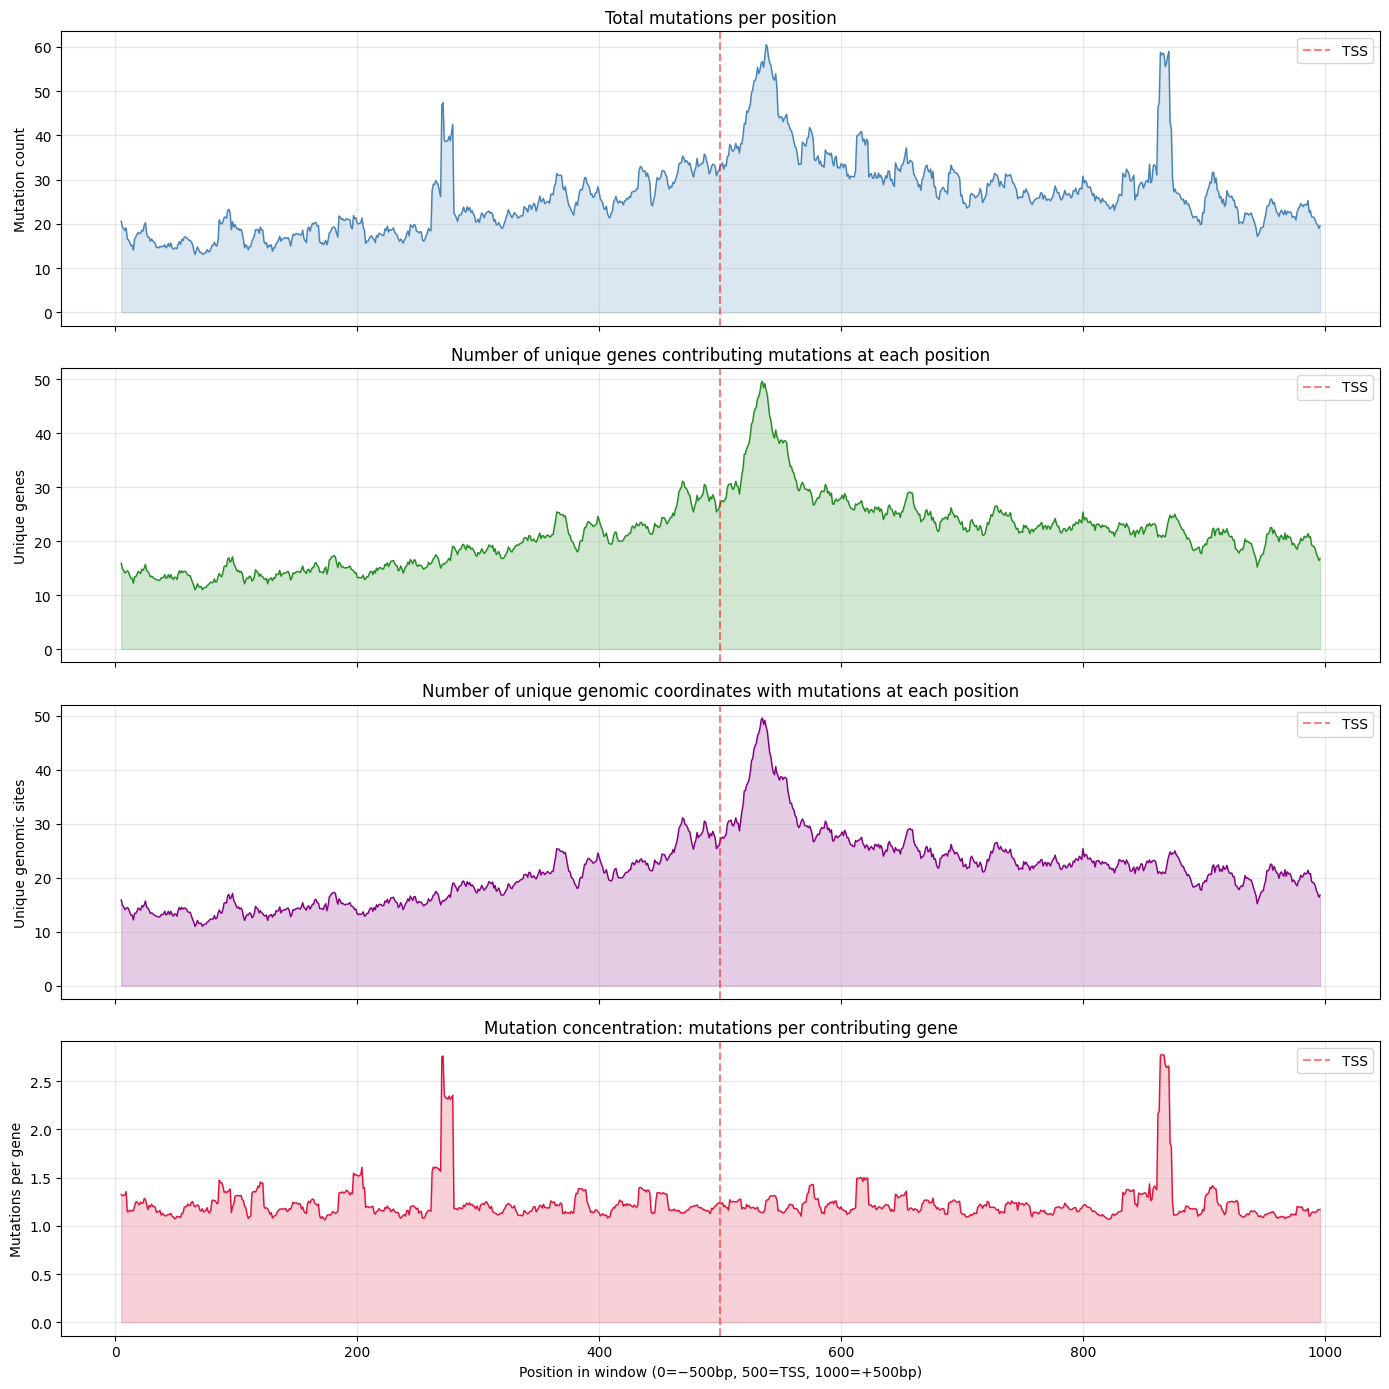


Interpretation:
If peaks in Panel 1 (mutations) are mirrored in Panel 2 (unique genes),
the signal is broad across many genes = likely biological.
If Panel 4 (muts/gene) spikes at the peak positions,
a few genes are contributing disproportionately = possible hotspot artifact.


In [26]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
smooth = 10

# Panel 1: Total mutations per position
ax = axes[0]
y = df_qc['mutations'].rolling(smooth, center=True).mean()
ax.plot(df_qc.index, y, color='steelblue', linewidth=1)
ax.fill_between(df_qc.index, y, alpha=0.2, color='steelblue')
ax.set_ylabel('Mutation count')
ax.set_title('Total mutations per position')
ax.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='TSS')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Unique genes per position
ax = axes[1]
y = df_qc['unique_genes'].rolling(smooth, center=True).mean()
ax.plot(df_qc.index, y, color='forestgreen', linewidth=1)
ax.fill_between(df_qc.index, y, alpha=0.2, color='forestgreen')
ax.set_ylabel('Unique genes')
ax.set_title('Number of unique genes contributing mutations at each position')
ax.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='TSS')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Unique genomic sites per position
ax = axes[2]
y = df_qc['unique_sites'].rolling(smooth, center=True).mean()
ax.plot(df_qc.index, y, color='purple', linewidth=1)
ax.fill_between(df_qc.index, y, alpha=0.2, color='purple')
ax.set_ylabel('Unique genomic sites')
ax.set_title('Number of unique genomic coordinates with mutations at each position')
ax.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='TSS')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 4: Mutations per gene (concentration)
ax = axes[3]
y = df_qc['muts_per_gene'].rolling(smooth, center=True).mean()
ax.plot(df_qc.index, y, color='crimson', linewidth=1)
ax.fill_between(df_qc.index, y, alpha=0.2, color='crimson')
ax.set_ylabel('Mutations per gene')
ax.set_xlabel('Position in window (0=−500bp, 500=TSS, 1000=+500bp)')
ax.set_title('Mutation concentration: mutations per contributing gene')
ax.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='TSS')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'output', 'QC_gene_breadth_per_position.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation:')
print('If peaks in Panel 1 (mutations) are mirrored in Panel 2 (unique genes),')
print('the signal is broad across many genes = likely biological.')
print('If Panel 4 (muts/gene) spikes at the peak positions,')
print('a few genes are contributing disproportionately = possible hotspot artifact.')

In [27]:
# Identify which genes contribute the most mutations at the peak positions
# Check the ~3 peak regions: upstream (~250), TSS (~500), downstream (~850)

peak_regions = {
    'upstream_peak (~250)': (220, 280),
    'TSS_peak (~500)': (480, 520),
    'downstream_peak (~850)': (820, 880),
    'baseline (100-150)': (100, 150),
}

print('Gene contribution analysis at peak vs baseline regions:')
print('=' * 80)

for label, (start, end) in peak_regions.items():
    # Collect all genes and their mutation counts in this region
    gene_counts = defaultdict(int)
    total = 0
    with open(strand_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            try:
                rp = int(parts[0])
            except ValueError:
                continue
            if start <= rp <= end:
                ensg = parts[2]
                gene_counts[ensg] += 1
                total += 1

    n_genes = len(gene_counts)
    top5 = sorted(gene_counts.items(), key=lambda x: -x[1])[:5]
    top5_total = sum(c for _, c in top5)

    print(f'\n{label} (positions {start}-{end}):')
    print(f'  Total mutations: {total}')
    print(f'  Unique genes: {n_genes}')
    print(f'  Top 5 genes account for {top5_total}/{total} ({top5_total/total*100:.1f}%) of mutations:')
    for gene, count in top5:
        print(f'    {gene}: {count} mutations ({count/total*100:.1f}%)')

Gene contribution analysis at peak vs baseline regions:

upstream_peak (~250) (positions 220-280):
  Total mutations: 1424
  Unique genes: 935
  Top 5 genes account for 317/1424 (22.3%) of mutations:
    ENSG00000165269: 202 mutations (14.2%)
    ENSG00000163162: 81 mutations (5.7%)
    ENSG00000204386: 16 mutations (1.1%)
    ENSG00000160949: 9 mutations (0.6%)
    ENSG00000196526: 9 mutations (0.6%)

TSS_peak (~500) (positions 480-520):
  Total mutations: 1410
  Unique genes: 1081
  Top 5 genes account for 65/1410 (4.6%) of mutations:
    ENSG00000164610: 24 mutations (1.7%)
    ENSG00000180205: 15 mutations (1.1%)
    ENSG00000088179: 9 mutations (0.6%)
    ENSG00000158710: 9 mutations (0.6%)
    ENSG00000177054: 8 mutations (0.6%)

downstream_peak (~850) (positions 820-880):
  Total mutations: 2031
  Unique genes: 1226
  Top 5 genes account for 394/2031 (19.4%) of mutations:
    ENSG00000110203: 169 mutations (8.3%)
    ENSG00000182156: 119 mutations (5.9%)
    ENSG00000104765: 36 

## 11.3c Filter Outlier Genes and Recompute Rates

Remove genes with disproportionate mutation counts at any single position (hotspot artifacts).
Then recompute mutation counts, rates, and re-plot to see the underlying biological pattern.

In [28]:
# Identify outlier genes: genes contributing > threshold mutations at ANY single position
# This catches genes like AQP7, FOLR3, ENPP7 that dominate the side peaks

OUTLIER_THRESHOLD = 50  # genes with >50 mutations at any one position are flagged

# Scan the mapped file to find per-gene per-position counts
gene_pos_counts = defaultdict(lambda: defaultdict(int))  # gene -> position -> count

with open(strand_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        try:
            rp = int(parts[0])
        except ValueError:
            continue
        ensg = parts[2]
        gene_pos_counts[ensg][rp] += 1

# Find genes whose max count at any position exceeds threshold
outlier_genes = set()
for gene, pos_dict in gene_pos_counts.items():
    max_count = max(pos_dict.values())
    if max_count > OUTLIER_THRESHOLD:
        outlier_genes.add(gene)

# Also report what they are
print(f'Outlier threshold: >{OUTLIER_THRESHOLD} mutations at any single position')
print(f'Outlier genes identified: {len(outlier_genes)}')
print()
for gene in sorted(outlier_genes):
    max_pos = max(gene_pos_counts[gene], key=gene_pos_counts[gene].get)
    max_val = gene_pos_counts[gene][max_pos]
    total = sum(gene_pos_counts[gene].values())
    print(f'  {gene}: max {max_val} mutations at position {max_pos}, total {total} mutations')

Outlier threshold: >50 mutations at any single position
Outlier genes identified: 6

  ENSG00000110203: max 169 mutations at position 866, total 170 mutations
  ENSG00000163162: max 81 mutations at position 266, total 85 mutations
  ENSG00000165269: max 201 mutations at position 274, total 203 mutations
  ENSG00000168175: max 52 mutations at position 542, total 55 mutations
  ENSG00000182156: max 119 mutations at position 868, total 122 mutations
  ENSG00000186193: max 53 mutations at position 617, total 54 mutations


In [29]:
# Write a filtered version of the strand-complemented file, excluding outlier genes
filtered_strand_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_geneID_strand_complement_filtered.txt')

kept = 0
removed = 0
with open(strand_file, 'r') as infile, open(filtered_strand_file, 'w') as outfile:
    for line in infile:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        ensg = parts[2]
        if ensg in outlier_genes:
            removed += 1
        else:
            outfile.write(line)
            kept += 1

print(f'Kept: {kept:,} mutations')
print(f'Removed: {removed:,} mutations from {len(outlier_genes)} outlier genes')
print(f'Filtered file: {filtered_strand_file}')

Kept: 25,745 mutations
Removed: 689 mutations from 6 outlier genes
Filtered file: ./somamutdb_data/output/somatic_mapped_TSS_1kb_geneID_strand_complement_filtered.txt


In [30]:
# Recount mutations by position x type from filtered file
counts_filt = {i: {mutation: 0 for mutation in mutation_types} for i in range(0, 1001)}

with open(filtered_strand_file, 'r') as f:
    for line in f:
        parts = line.split()
        if parts[0] == 'NA':
            continue
        try:
            row_index = int(parts[0])
        except ValueError:
            continue
        if 0 <= row_index <= 1000:
            mutation_type = parts[1]
            if mutation_type in mutation_types:
                counts_filt[row_index][mutation_type] += 1

df_counts_filt = pd.DataFrame.from_dict(counts_filt, orient='index', columns=mutation_types)

# Compute filtered rates on common_idx (same nucleotide denominators)
df_rates_filt = pd.DataFrame(index=common_idx, columns=mutation_types, dtype=float)
for mut in mutation_types:
    denom_col = denom_map_all[mut]
    denom = nuc.loc[common_idx, denom_col].values.astype(float)
    denom[denom == 0] = np.nan
    raw_rate = df_counts_filt.loc[common_idx, mut].values / denom
    df_rates_filt[mut] = raw_rate / (1 - raw_rate)

# Overall filtered rate
total_muts_filt = df_counts_filt.loc[common_idx].sum(axis=1)
raw_overall_filt = total_muts_filt.values / total_nucs_per_pos
overall_rate_filt = raw_overall_filt / (1 - raw_overall_filt)

print(f'Total filtered mutations in window: {df_counts_filt.sum().sum():,.0f}')

Total filtered mutations in window: 25,745


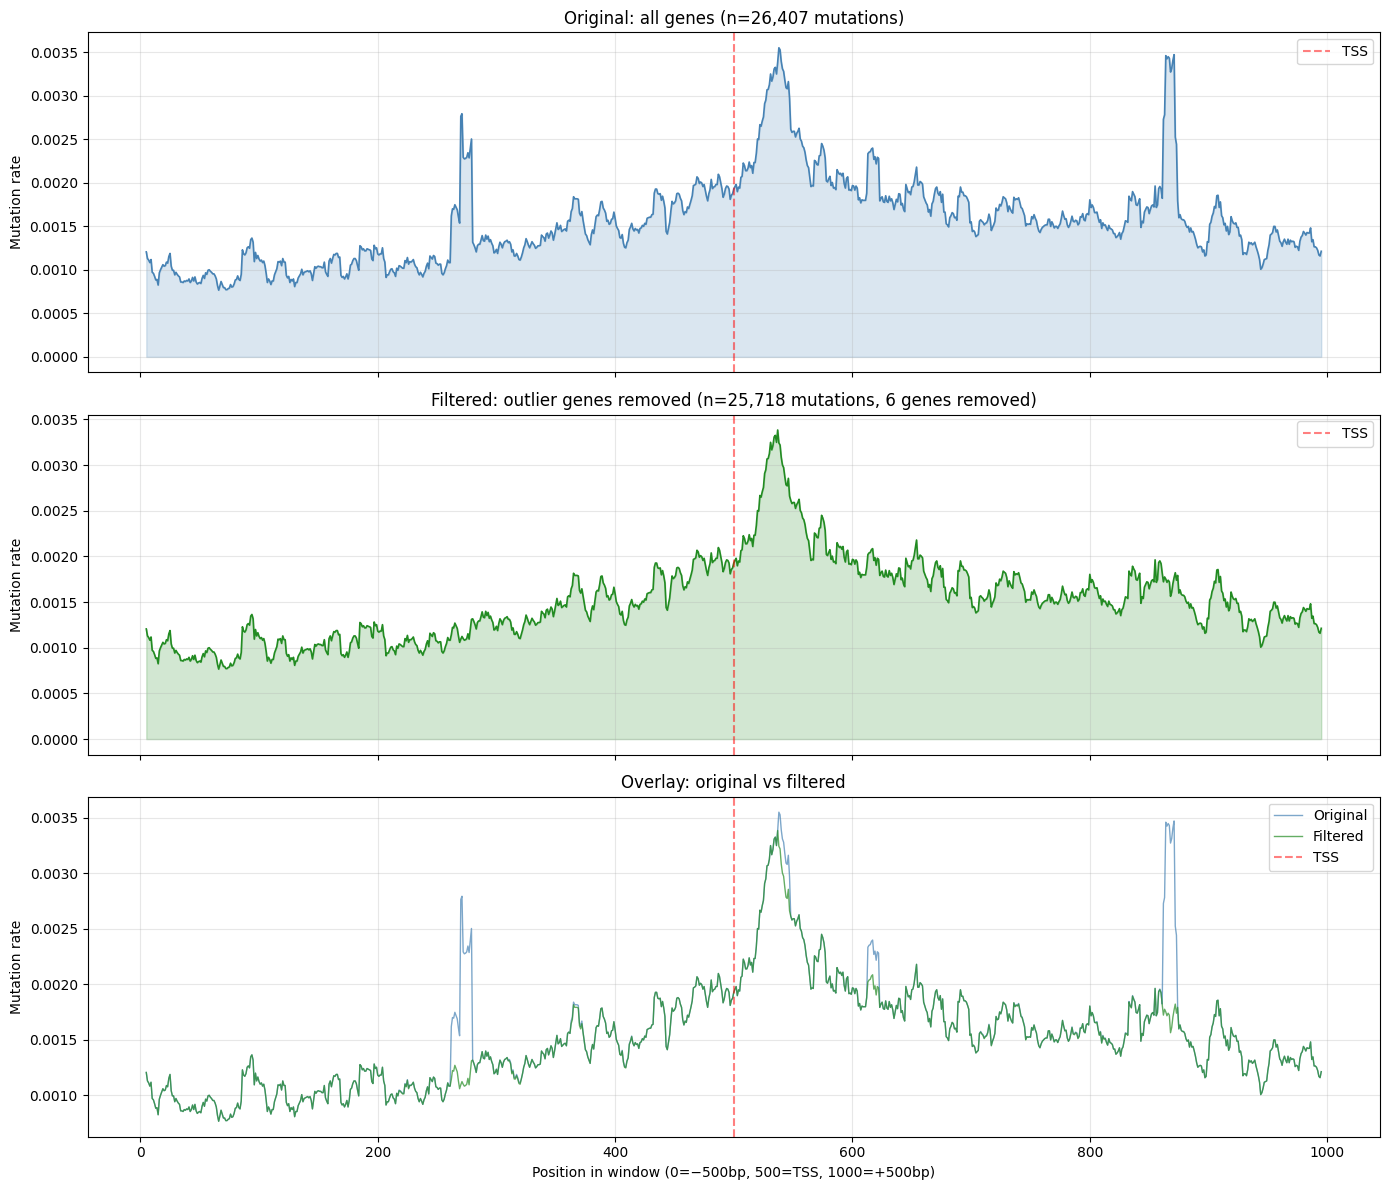


If the side peaks disappear in the filtered plot, they were driven by outlier genes.
If the TSS peak remains, it reflects genuine transcription-associated hypermutability.


In [31]:
# Plot: compare original vs filtered overall rate
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
smooth = 10

# Panel 1: Original
ax = axes[0]
rate_s = pd.Series(overall_rate_all, index=common_idx)
y = rate_s.rolling(smooth, center=True).mean()
ax.plot(common_idx, y, color='steelblue', linewidth=1.2)
ax.fill_between(common_idx, y, alpha=0.2, color='steelblue')
ax.set_ylabel('Mutation rate')
ax.set_title(f'Original: all genes (n={df_counts.loc[common_idx].sum().sum():,.0f} mutations)')
ax.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='TSS')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Filtered
ax = axes[1]
rate_f = pd.Series(overall_rate_filt, index=common_idx)
y2 = rate_f.rolling(smooth, center=True).mean()
ax.plot(common_idx, y2, color='forestgreen', linewidth=1.2)
ax.fill_between(common_idx, y2, alpha=0.2, color='forestgreen')
ax.set_ylabel('Mutation rate')
ax.set_title(f'Filtered: outlier genes removed (n={df_counts_filt.loc[common_idx].sum().sum():,.0f} mutations, {len(outlier_genes)} genes removed)')
ax.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='TSS')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Overlay
ax = axes[2]
ax.plot(common_idx, y, color='steelblue', linewidth=1, alpha=0.7, label='Original')
ax.plot(common_idx, y2, color='forestgreen', linewidth=1, alpha=0.7, label='Filtered')
ax.set_ylabel('Mutation rate')
ax.set_xlabel('Position in window (0=−500bp, 500=TSS, 1000=+500bp)')
ax.set_title('Overlay: original vs filtered')
ax.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='TSS')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'output', 'mutation_rate_original_vs_filtered.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nIf the side peaks disappear in the filtered plot, they were driven by outlier genes.')
print('If the TSS peak remains, it reflects genuine transcription-associated hypermutability.')

## 11.4 Plot: Overall mutation rate around TSS (outliers removed)

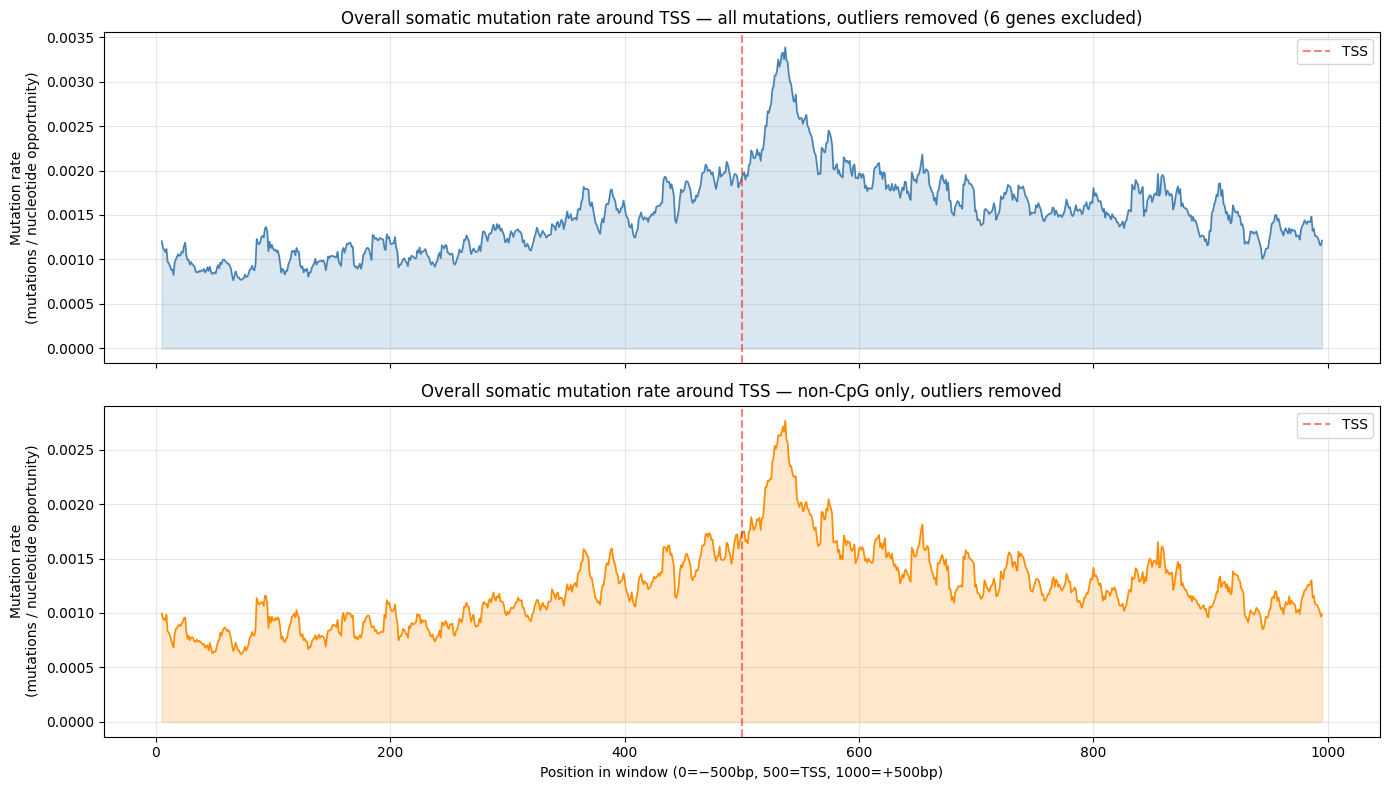

Filtered all-mutation rates saved to: ./somamutdb_data/output/somatic_mutation_rates_all_filtered.csv
Filtered non-CpG mutation rates saved to: ./somamutdb_data/output/somatic_mutation_rates_nonCpG_filtered.csv
Filtered count matrices saved.


In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
smooth = 10

# Panel 1: Overall rate — all mutations (filtered)
ax1 = axes[0]
rate_s = pd.Series(overall_rate_filt, index=common_idx)
rate_smooth = rate_s.rolling(smooth, center=True).mean()
ax1.plot(common_idx, rate_smooth, color='steelblue', linewidth=1.2)
ax1.fill_between(common_idx, rate_smooth, alpha=0.2, color='steelblue')
ax1.set_ylabel('Mutation rate\n(mutations / nucleotide opportunity)')
ax1.set_title(f'Overall somatic mutation rate around TSS — all mutations, outliers removed ({len(outlier_genes)} genes excluded)')
ax1.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='TSS')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Overall rate — non-CpG (filtered)
# First recount non-CpG from filtered file
# We need to also filter the non-CpG file
counts_noncpg_filt = {j: {mutation: 0 for mutation in mutation_types} for j in range(0, 1001)}

# Re-read the surround file but skip outlier genes
with open(surround_file, 'r') as f:
    for line in f:
        columns = line.split()
        if len(columns) < 5:
            continue
        ensg = columns[2]
        if ensg in outlier_genes:
            continue
        try:
            rp = int(columns[0])
        except ValueError:
            continue
        if not (0 <= rp <= 1000):
            continue
        mutation = columns[1]
        sequence = columns[-1].upper()
        # Check if CpG
        is_cpg = False
        if (mutation == 'C>T' and len(sequence) >= 3 and sequence[2] == 'G') or \
           (mutation == 'G>A' and len(sequence) >= 1 and sequence[0] == 'C'):
            is_cpg = True
        if not is_cpg:
            if mutation in mutation_types:
                counts_noncpg_filt[rp][mutation] += 1

df_noncpg_filt = pd.DataFrame.from_dict(counts_noncpg_filt, orient='index', columns=mutation_types)

# Compute non-CpG filtered rates
df_rates_noncpg_filt = pd.DataFrame(index=common_idx_nc, columns=mutation_types, dtype=float)
for mut in mutation_types:
    denom_col = denom_map_noncpg[mut]
    denom = nuc.loc[common_idx_nc, denom_col].values.astype(float)
    denom[denom == 0] = np.nan
    raw_rate = df_noncpg_filt.loc[common_idx_nc, mut].values / denom
    df_rates_noncpg_filt[mut] = raw_rate / (1 - raw_rate)

noncpg_muts_filt = df_noncpg_filt.loc[common_idx_nc].sum(axis=1)
total_nucs_nc_arr = (
    nuc.loc[common_idx_nc, 'A Content'].values +
    nuc.loc[common_idx_nc, 'T Content'].values +
    nuc.loc[common_idx_nc, 'G Content'].values +
    nuc.loc[common_idx_nc, 'C Content'].values
).astype(float)
total_nucs_nc_arr[total_nucs_nc_arr == 0] = np.nan
raw_nc_filt = noncpg_muts_filt.values / total_nucs_nc_arr
overall_rate_noncpg_filt = raw_nc_filt / (1 - raw_nc_filt)

ax2 = axes[1]
rate_nc_s = pd.Series(overall_rate_noncpg_filt, index=common_idx_nc)
rate_smooth_nc = rate_nc_s.rolling(smooth, center=True).mean()
ax2.plot(common_idx_nc, rate_smooth_nc, color='darkorange', linewidth=1.2)
ax2.fill_between(common_idx_nc, rate_smooth_nc, alpha=0.2, color='darkorange')
ax2.set_ylabel('Mutation rate\n(mutations / nucleotide opportunity)')
ax2.set_xlabel('Position in window (0=−500bp, 500=TSS, 1000=+500bp)')
ax2.set_title('Overall somatic mutation rate around TSS — non-CpG only, outliers removed')
ax2.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='TSS')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'output', 'overall_mutation_rate_TSS_filtered.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save filtered rates to files
# All mutations filtered rates
df_rates_filt_out = df_rates_filt.copy()
df_rates_filt_out['overall'] = overall_rate_filt
rates_filt_all_file = os.path.join(WORK_DIR, 'output', 'somatic_mutation_rates_all_filtered.csv')
df_rates_filt_out.to_csv(rates_filt_all_file, index_label='Position')
print(f'Filtered all-mutation rates saved to: {rates_filt_all_file}')

# Non-CpG filtered rates
df_rates_noncpg_filt_out = df_rates_noncpg_filt.copy()
df_rates_noncpg_filt_out['overall'] = overall_rate_noncpg_filt
rates_filt_nc_file = os.path.join(WORK_DIR, 'output', 'somatic_mutation_rates_nonCpG_filtered.csv')
df_rates_noncpg_filt_out.to_csv(rates_filt_nc_file, index_label='Position')
print(f'Filtered non-CpG mutation rates saved to: {rates_filt_nc_file}')

# Also save the filtered count matrices
df_counts_filt.to_csv(os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_count_filtered.csv'), index_label='Position')
df_noncpg_filt.to_csv(os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_nonCpG_count_filtered.csv'), index_label='Position')
print(f'Filtered count matrices saved.')

## 11.5 Plot: Individual mutation type rates — all mutations, outliers removed

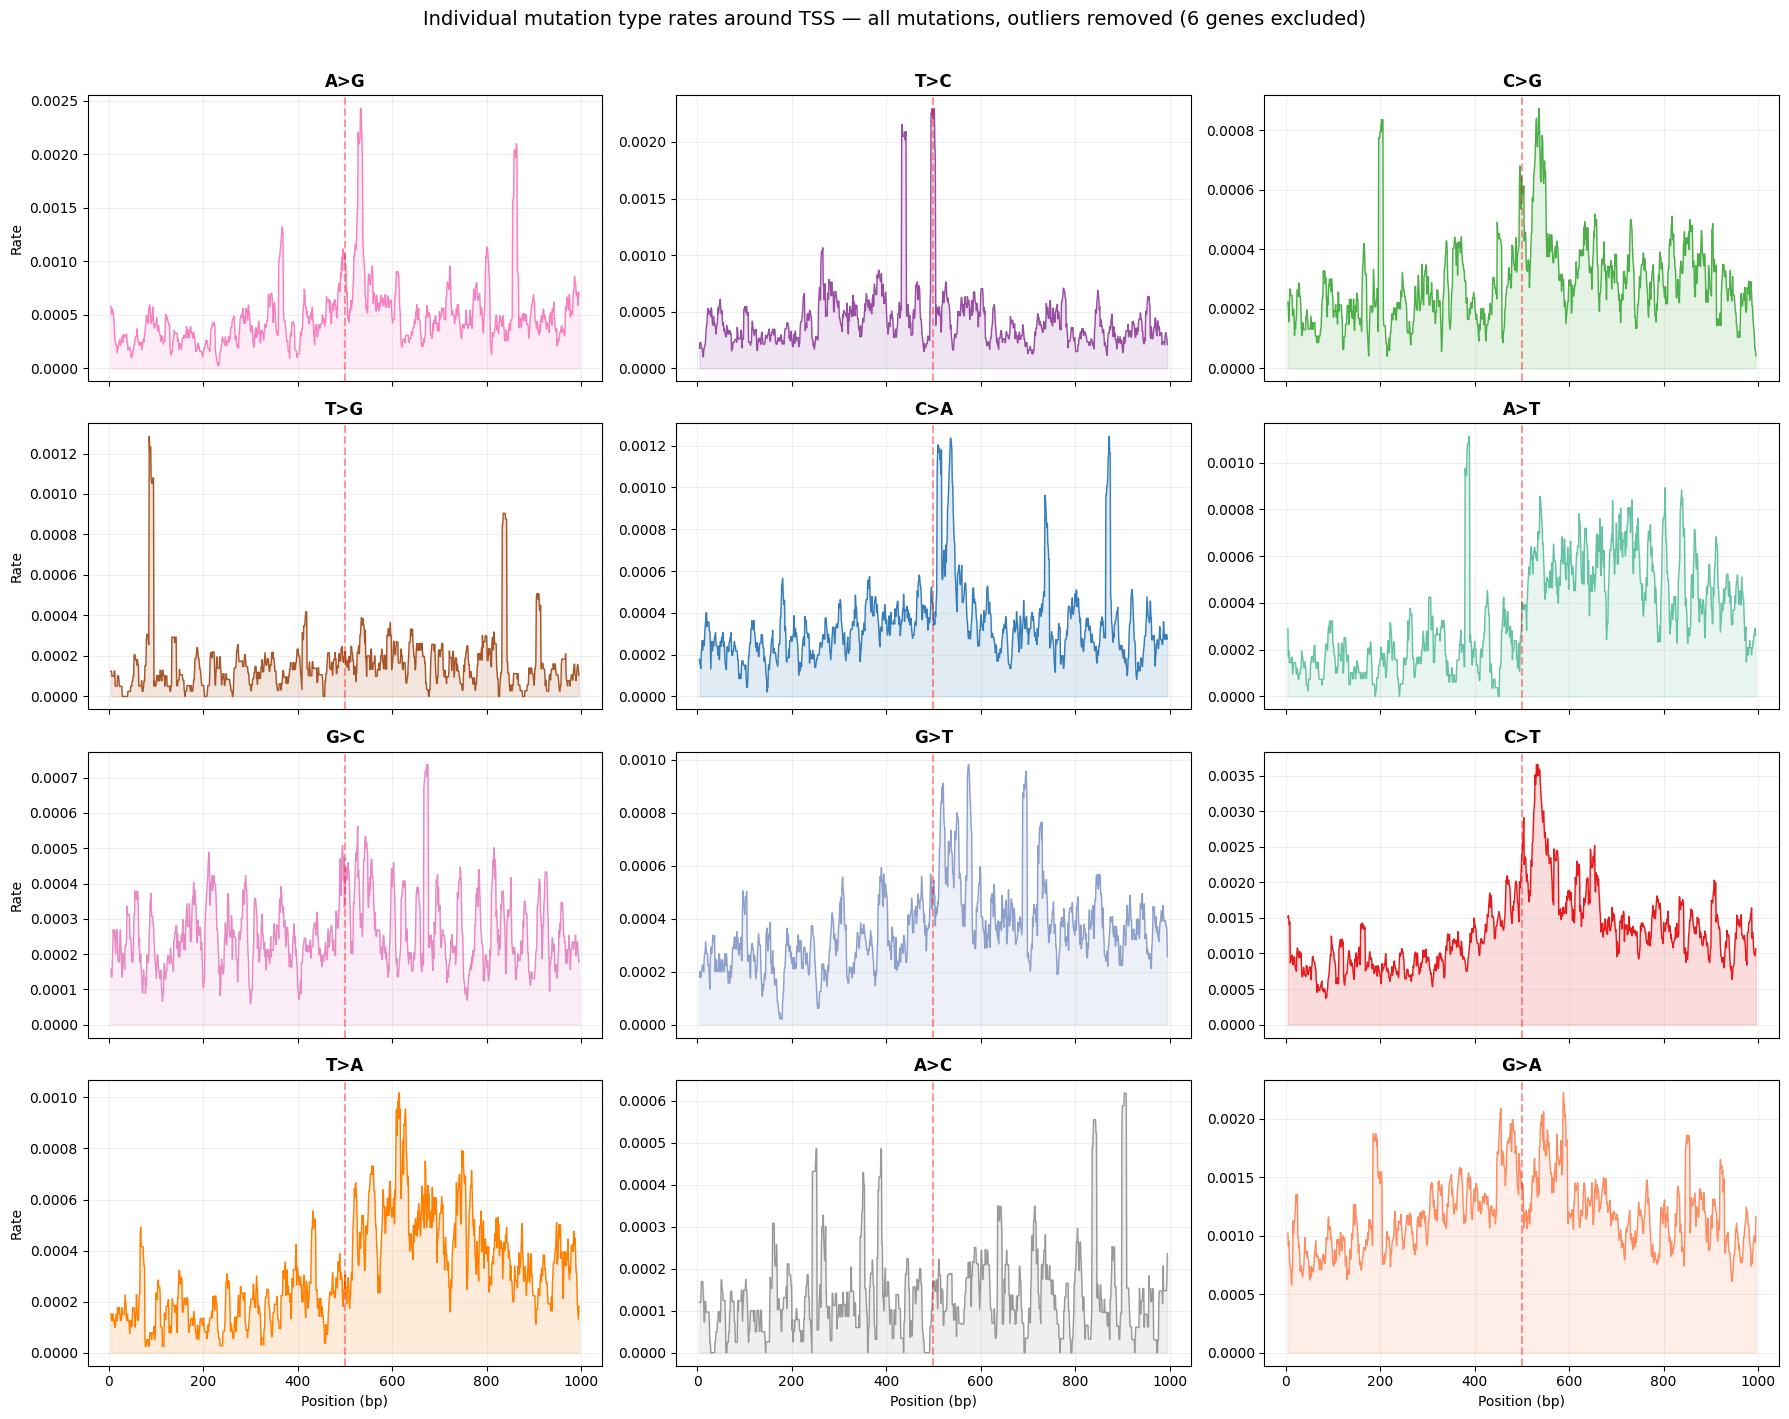

In [33]:
# 4x3 grid for 12 mutation types (filtered)
fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharex=True)
smooth = 10

colors = {
    'C>T': '#e41a1c', 'C>A': '#377eb8', 'C>G': '#4daf4a',
    'T>C': '#984ea3', 'T>A': '#ff7f00', 'T>G': '#a65628',
    'A>G': '#f781bf', 'A>C': '#999999', 'A>T': '#66c2a5',
    'G>A': '#fc8d62', 'G>T': '#8da0cb', 'G>C': '#e78ac3',
}

for idx, mut in enumerate(mutation_types):
    row = idx // 3
    col = idx % 3
    ax = axes[row][col]

    rate = df_rates_filt[mut].rolling(smooth, center=True).mean()
    ax.plot(df_rates_filt.index, rate, color=colors.get(mut, 'gray'), linewidth=1)
    ax.fill_between(df_rates_filt.index, rate, alpha=0.15, color=colors.get(mut, 'gray'))
    ax.set_title(mut, fontsize=12, fontweight='bold')
    ax.axvline(x=500, color='red', linestyle='--', alpha=0.4)
    ax.grid(True, alpha=0.2)
    if col == 0:
        ax.set_ylabel('Rate')
    if row == 3:
        ax.set_xlabel('Position (bp)')

fig.suptitle(f'Individual mutation type rates around TSS — all mutations, outliers removed ({len(outlier_genes)} genes excluded)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'output', 'individual_mutation_rates_all_filtered.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11.6 Plot: Individual mutation type rates — non-CpG, outliers removed

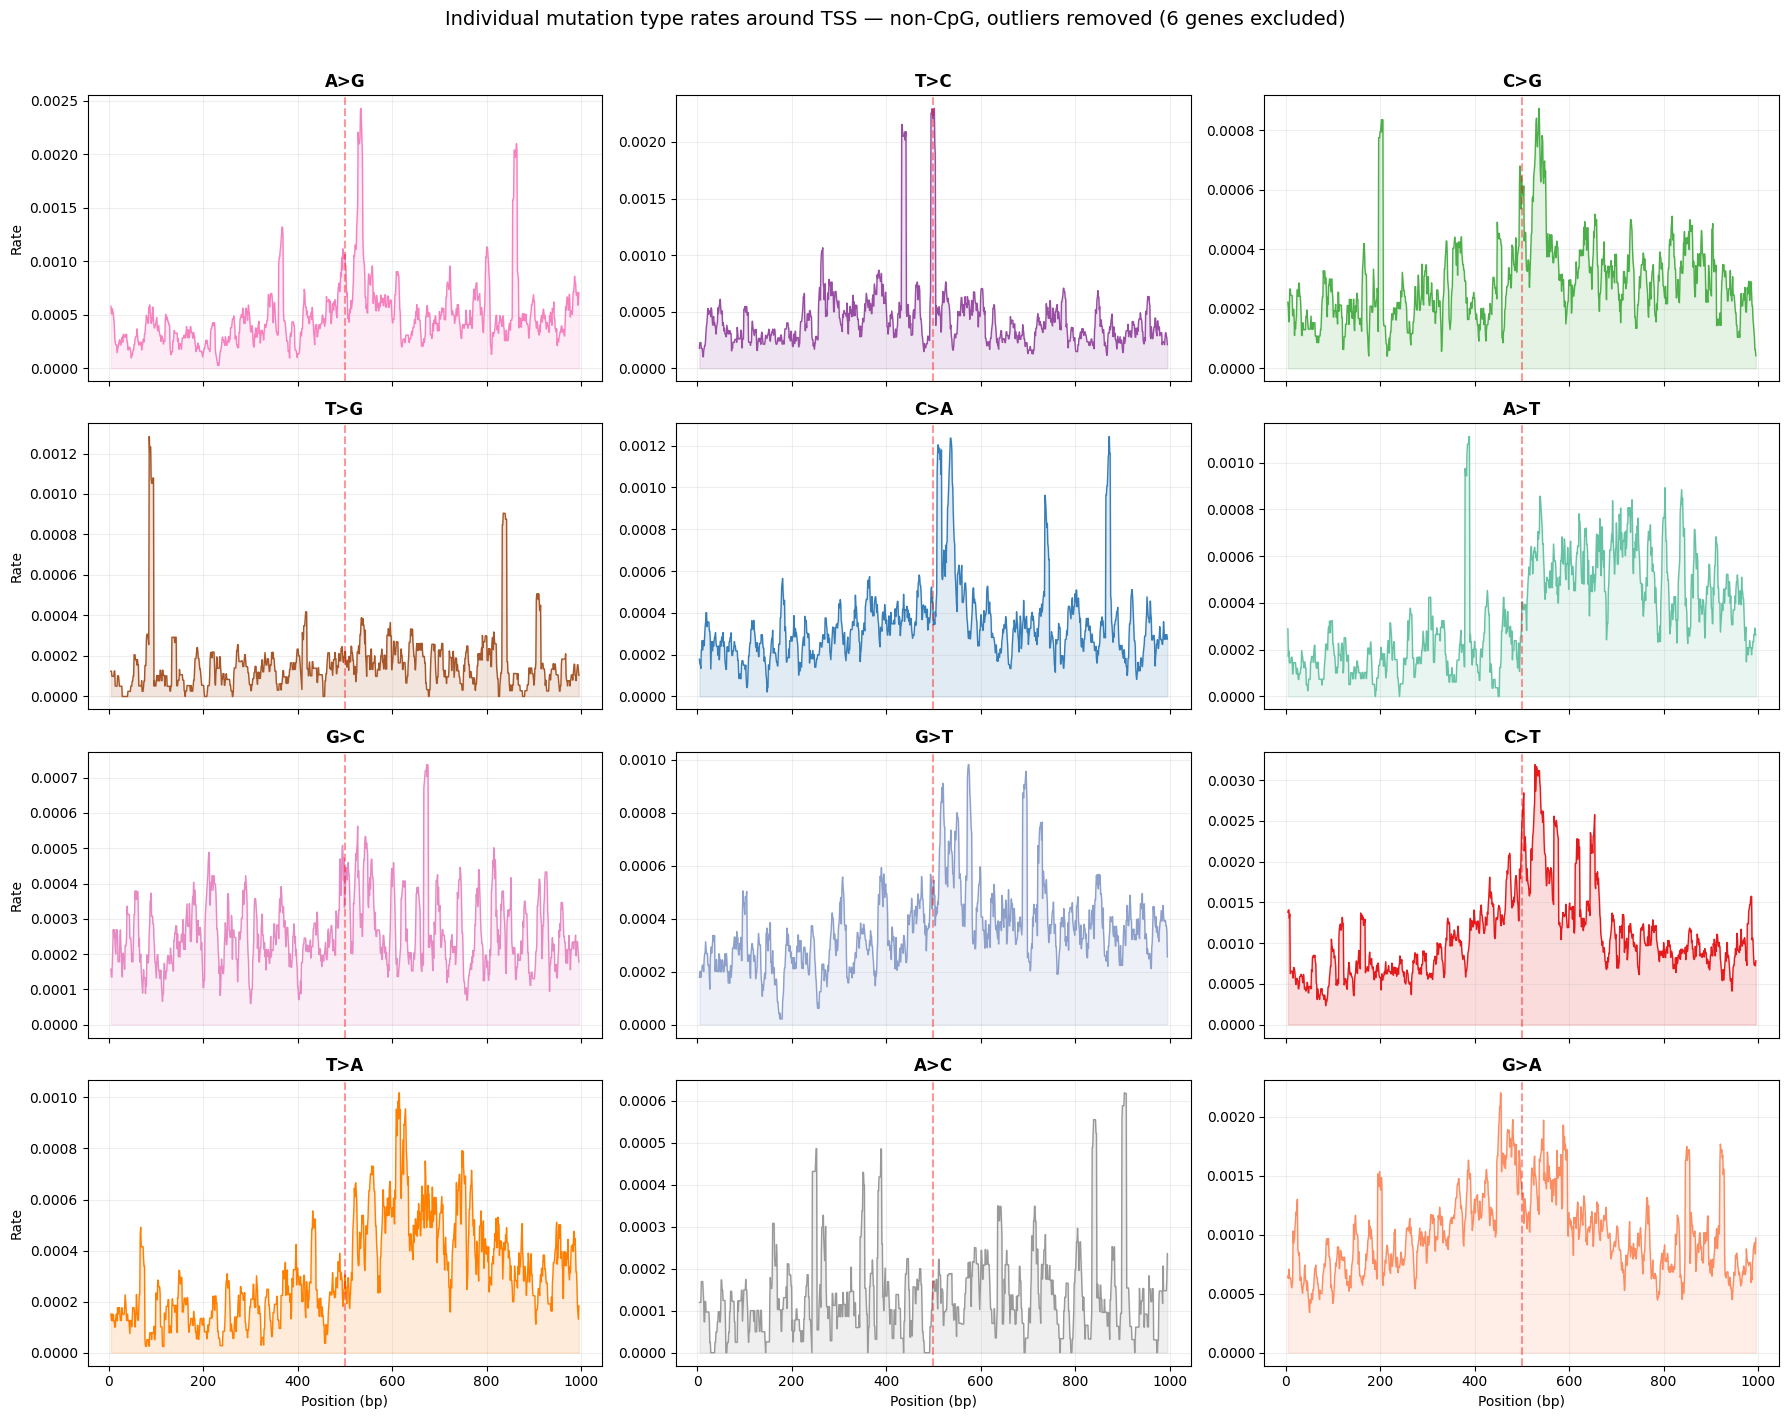

In [34]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharex=True)
smooth = 10

for idx, mut in enumerate(mutation_types):
    row = idx // 3
    col = idx % 3
    ax = axes[row][col]

    rate = df_rates_noncpg_filt[mut].rolling(smooth, center=True).mean()
    ax.plot(df_rates_noncpg_filt.index, rate, color=colors.get(mut, 'gray'), linewidth=1)
    ax.fill_between(df_rates_noncpg_filt.index, rate, alpha=0.15, color=colors.get(mut, 'gray'))
    ax.set_title(mut, fontsize=12, fontweight='bold')
    ax.axvline(x=500, color='red', linestyle='--', alpha=0.4)
    ax.grid(True, alpha=0.2)
    if col == 0:
        ax.set_ylabel('Rate')
    if row == 3:
        ax.set_xlabel('Position (bp)')

fig.suptitle(f'Individual mutation type rates around TSS — non-CpG, outliers removed ({len(outlier_genes)} genes excluded)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'output', 'individual_mutation_rates_nonCpG_filtered.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11.7 Plot: All 12 types overlaid — outliers removed

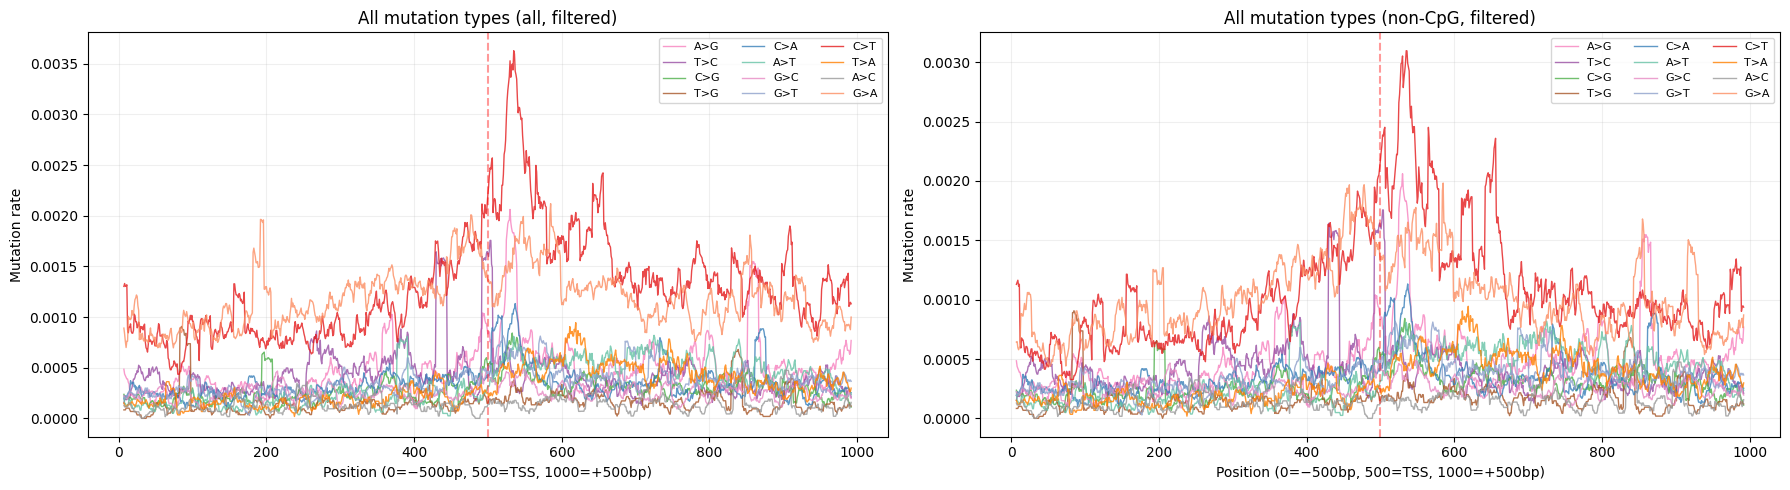

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
smooth = 15

# Left: all mutations (filtered)
ax = axes[0]
for mut in mutation_types:
    rate = df_rates_filt[mut].rolling(smooth, center=True).mean()
    ax.plot(df_rates_filt.index, rate, color=colors.get(mut, 'gray'), linewidth=1, label=mut, alpha=0.8)
ax.set_xlabel('Position (0=−500bp, 500=TSS, 1000=+500bp)')
ax.set_ylabel('Mutation rate')
ax.set_title('All mutation types (all, filtered)')
ax.axvline(x=500, color='red', linestyle='--', alpha=0.4)
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(True, alpha=0.2)

# Right: non-CpG (filtered)
ax = axes[1]
for mut in mutation_types:
    rate = df_rates_noncpg_filt[mut].rolling(smooth, center=True).mean()
    ax.plot(df_rates_noncpg_filt.index, rate, color=colors.get(mut, 'gray'), linewidth=1, label=mut, alpha=0.8)
ax.set_xlabel('Position (0=−500bp, 500=TSS, 1000=+500bp)')
ax.set_ylabel('Mutation rate')
ax.set_title('All mutation types (non-CpG, filtered)')
ax.axvline(x=500, color='red', linestyle='--', alpha=0.4)
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'output', 'mutation_rates_overlaid_filtered.png'), dpi=150, bbox_inches='tight')
plt.show()

---
# 12. Output Files Summary

| File | Description |
|------|-------------|
| `somatic_mutations_reformatted.tsv` | All SNVs in `chr  pos  ref>alt` format |
| `somatic_mapped_TSS_1kb_geneID.txt` | Mutations mapped to TSS windows |
| `somatic_mapped_TSS_1kb_geneID_strand_complement.txt` | Reverse complemented for − strand |
| `somatic_mapped_TSS_1kb_count.csv` | Position × mutation type count matrix (all) |
| `somatic_mapped_TSS_1kb_nonCpG_count.csv` | Position × mutation type count matrix (non-CpG) |
| `somatic_mapped_TSS_1kb_CpG.txt` | CpG mutations only |
| `somatic_mapped_TSS_1kb_nonCpG.txt` | Non-CpG mutations only |
| `TSS_1kb_nucleotide_content.csv` | A/T/G/C counts per position |
| `TSS_1kb_nucleotide_content_CpG.txt` | Nucleotide counts with CpG context |
| `somatic_mutation_rates_all.csv` | Per-position rates for each mutation type (all) |
| `somatic_mutation_rates_nonCpG.csv` | Per-position rates for each mutation type (non-CpG) |
| `overall_mutation_rate_TSS.png` | Overall rate profile |
| `individual_mutation_rates_all.png` | 4×3 grid of individual type rates |
| `individual_mutation_rates_nonCpG.png` | 4×3 grid non-CpG type rates |
| `mutation_rates_overlaid.png` | All types overlaid on one plot |

---
# Make VCF

In [ ]:
# ============================================================
# Extract VCF from strand-complement file for COSMIC SBS analysis
# ============================================================
# Input: somatic_mapped_TSS_1kb_geneID_strand_complement_filtered.txt
# Output: VCF file compatible with SigProfiler / MutationalPatterns
#
# The strand-complement file has mutations in sense-strand orientation
# (already reverse-complemented for - strand genes).
# SigProfiler looks up trinucleotide context from the REFERENCE GENOME,
# so for - strand genes we need to complement back to reference orientation.

# --- SETTINGS ---
POS_START = 500   # TSS position in your window
POS_END = 600     # TSS + 100bp downstream

input_file = os.path.join(WORK_DIR, 'output', 'somatic_mapped_TSS_1kb_geneID_strand_complement_filtered.txt')
vcf_output = os.path.join(WORK_DIR, 'output', f'somatic_TSS_pos{POS_START}-{POS_END}_for_SBS.vcf')

# Complement map to undo strand correction for VCF output
complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}

# --- PARSE ---
# File format: range_position mutation ENSG ENST chr coord direction
# e.g.: 502 C>T ENSG00000187634 ENST00000616016 1 923925 +

mutations_collected = []

with open(input_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        try:
            rp = int(parts[0])
        except ValueError:
            continue
        if POS_START <= rp <= POS_END:
            mutation = parts[1]
            chrom = parts[4]
            coord = int(parts[5])
            direction = parts[6]

            ref_sense, alt_sense = mutation.split('>')

            # For + strand: sense == reference genome, no change
            # For - strand: complement back to reference genome orientation
            if direction == '+':
                ref_vcf = ref_sense
                alt_vcf = alt_sense
            else:
                ref_vcf = complement[ref_sense]
                alt_vcf = complement[alt_sense]

            mutations_collected.append((chrom, coord, ref_vcf, alt_vcf))

# --- SORT ---
def chrom_sort_key(x):
    c = x[0]
    try:
        return (0, int(c))
    except ValueError:
        return (1, c)

mutations_collected.sort(key=lambda x: (chrom_sort_key(x), x[1]))

# --- WRITE VCF ---
with open(vcf_output, 'w') as vcf:
    vcf.write('##fileformat=VCFv4.2\n')
    vcf.write('##source=SomaMutDB_TSS_mapping\n')
    vcf.write(f'##INFO=<ID=TSS_REGION,Number=0,Type=Flag,Description="Mutations in TSS+0 to +{POS_END-POS_START}bp region">\n')
    vcf.write('##reference=GRCh38\n')
    vcf.write('#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n')
    for chrom, pos, ref, alt in mutations_collected:
        vcf.write(f'{chrom}\t{pos}\t.\t{ref}\t{alt}\t.\tPASS\tTSS_REGION\n')

print(f'VCF written to: {vcf_output}')
print(f'Total mutations in positions {POS_START}-{POS_END}: {len(mutations_collected):,}')

# --- SUMMARY ---
from collections import Counter
spectrum = Counter()
for _, _, ref, alt in mutations_collected:
    spectrum[f'{ref}>{alt}'] += 1

print(f'\nMutation spectrum (reference genome orientation):')
for mut, count in sorted(spectrum.items(), key=lambda x: -x[1]):
    print(f'  {mut}: {count} ({count/len(mutations_collected)*100:.1f}%)')